In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib import style
style.use('ggplot')

import warnings
warnings.filterwarnings('ignore')

In [3]:
titanic = pd.read_csv('train.csv')
titanic.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [4]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [12]:
titanic.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [13]:
titanic.nunique()

PassengerId    891
Survived         2
Pclass           3
Name           891
Sex              2
Age             88
SibSp            7
Parch            7
Ticket         681
Fare           248
Cabin          147
Embarked         3
dtype: int64

In [14]:
print('Survived : ', titanic.Survived.unique())
print('PClasses : ', titanic.Pclass.unique())
print('Gender   : ', titanic.Sex.unique())
print('Embarked : ', titanic.Embarked.dropna().unique())

Survived :  [0 1]
PClasses :  [3 1 2]
Gender   :  ['male' 'female']
Embarked :  ['S' 'C' 'Q']


# Preprocessing

### Check for duplicates
- If duplicate then drop them

In [15]:
titanic.duplicated().sum()

0

In [16]:
titanic.drop_duplicates(inplace = True)           # to remove duplicates

### Dealing with missing values

In [17]:
titanic.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

**If number of missing values in a column is large wrt total values then dropping that column is a suitable strategy**

In [18]:
titanic.drop('Cabin', axis = 1, inplace = True)
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


**In numerical Columns missing values can be replaced by the mean or median of that column**

<Axes: xlabel='Age', ylabel='Density'>

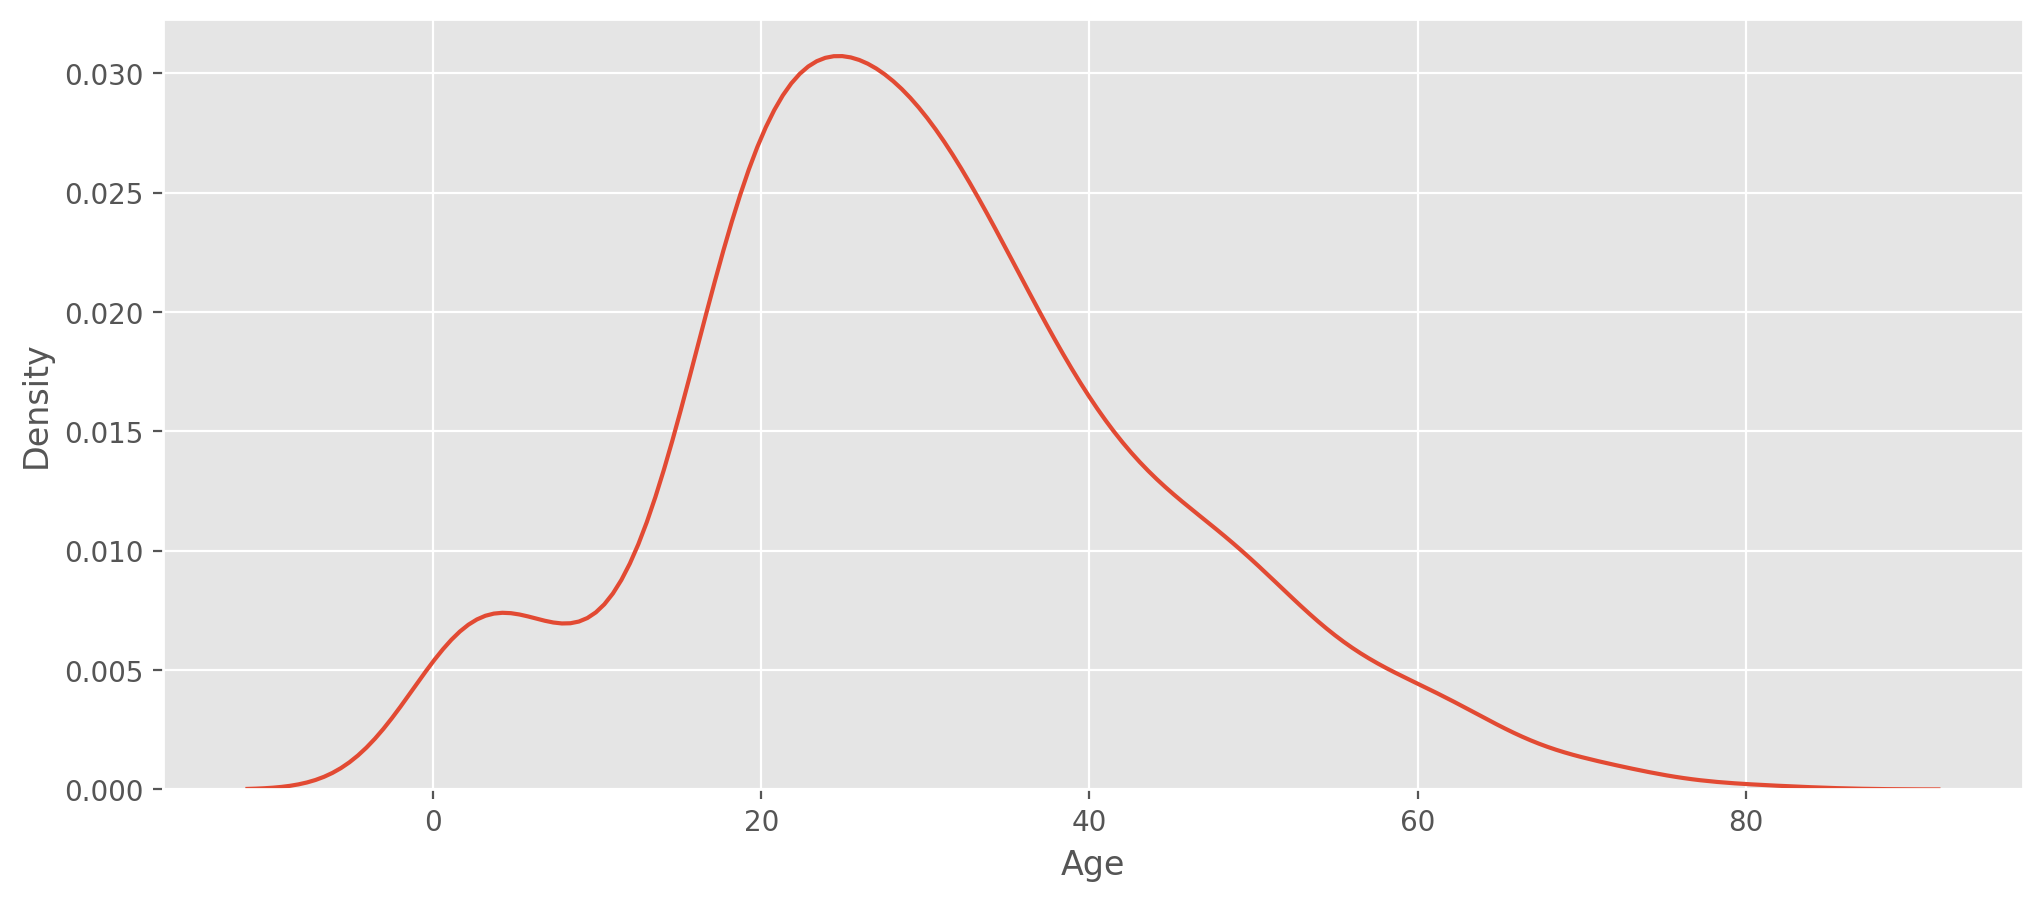

In [19]:
plt.figure(figsize = (12,5), dpi = 200)
sns.distplot(titanic.Age, hist = False)

In [20]:
mean_age = titanic.Age.mean()
titanic.Age.replace(np.nan, mean_age, inplace = True)

titanic.Age.isnull().sum()

0

**In categorical columns missing values can be replaced by mode**

In [21]:
mode_emb = titanic.Embarked.dropna().mode()[0]
titanic.Embarked.replace(np.nan, mode_emb, inplace = True)

titanic.Embarked.isnull().sum()

0

## Strategies to deal with missing values
- If number of missing values in a column is large wrt total values then dropping that column is a suitable strategy
- In numerical Columns missing values can be replaced by the mean or median of that column
- In categorical columns missing values can be replaced by mode
- If number of rows having missing values is very small wrt total rows then these rows can be dropped
                    - titanic.dropna(inplace= True)

In [22]:
# Creating a new column family_members by adding SibSp and Parch
titanic['family_members'] = titanic.SibSp + titanic.Parch
titanic.drop(['SibSp', 'Parch'], inplace = True, axis = 1)

titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,Ticket,Fare,Embarked,family_members
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,A/5 21171,7.2500,S,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,PC 17599,71.2833,C,1
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,STON/O2. 3101282,7.9250,S,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,113803,53.1000,S,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,373450,8.0500,S,0


# ============================================================

# Exploratory Data Analysis

<AxesSubplot:xlabel='Survived', ylabel='count'>

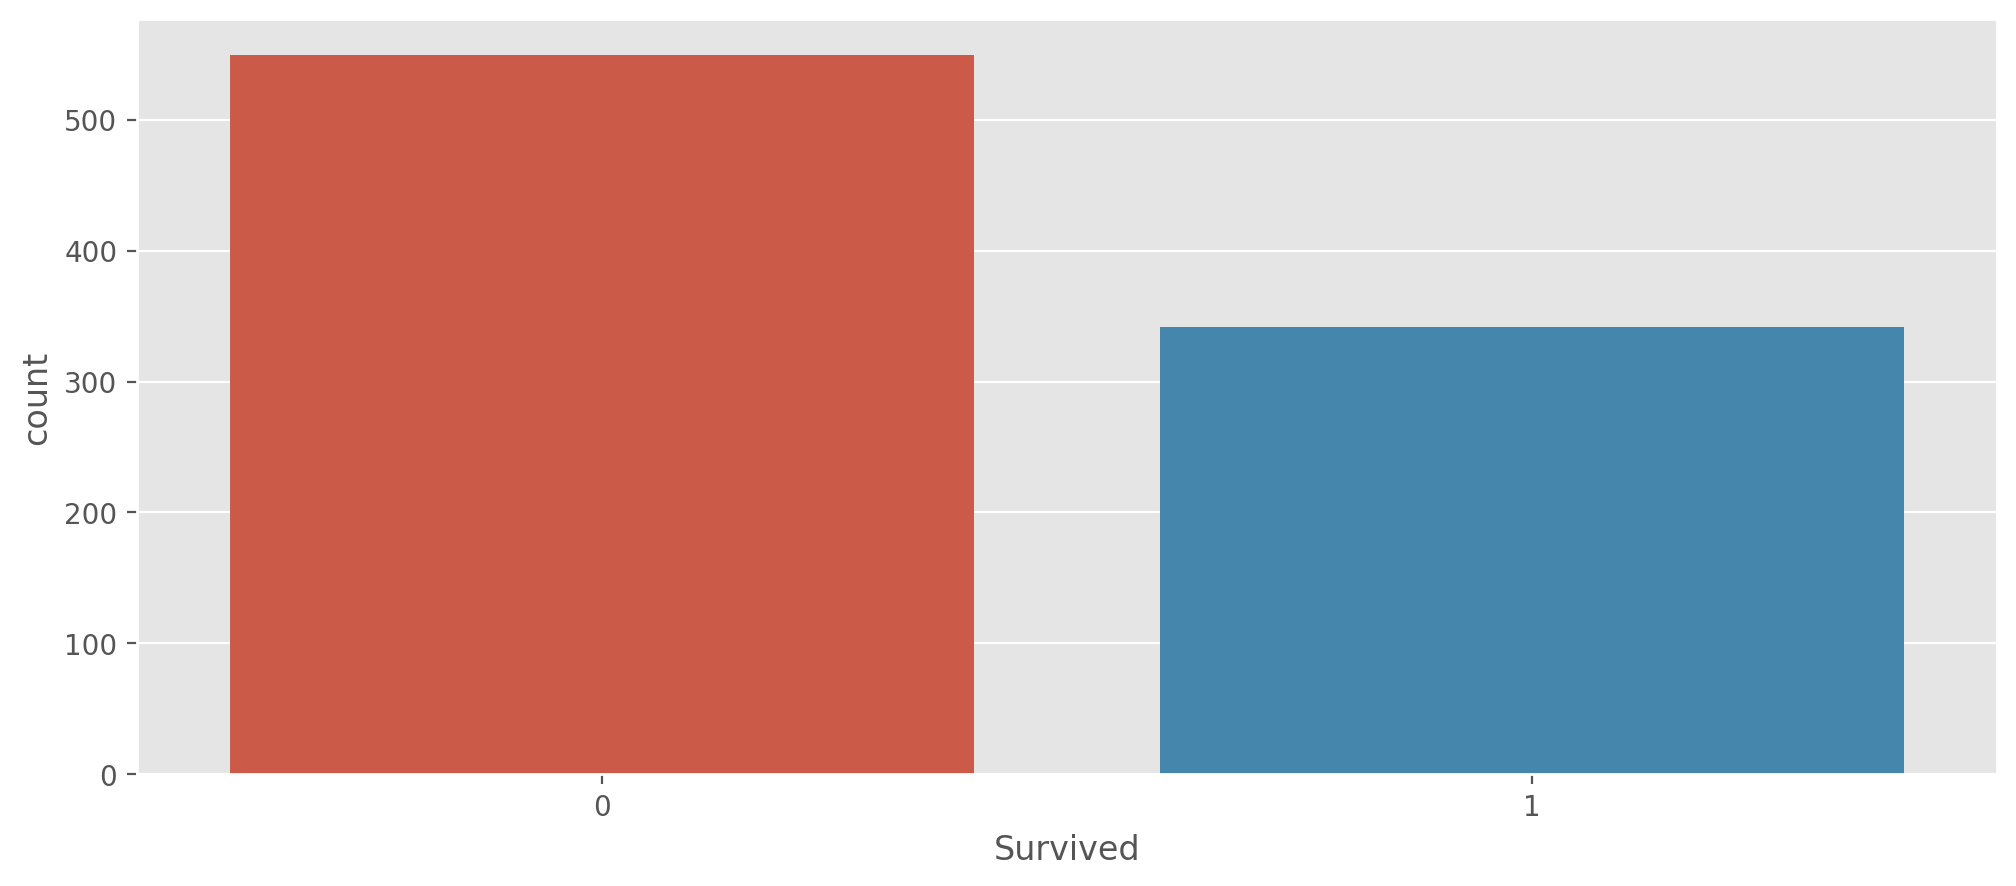

In [27]:
# To check how many survived and how many were dead
plt.figure(figsize = (12,5), dpi = 200)
sns.countplot('Survived', data = titanic)

In [32]:
titanic.Survived.value_counts()

0    549
1    342
Name: Survived, dtype: int64

In [36]:
survival_ratio = titanic.Survived.value_counts(normalize = True)
print('Percentage of Survivors : ', round(survival_ratio[1] * 100,2),'%')
print('Percentage of dead      : ', round(survival_ratio[0] * 100,2),'%')

Percentage of Survivors :  38.38 %
Percentage of dead      :  61.62 %


<AxesSubplot:xlabel='Sex', ylabel='count'>

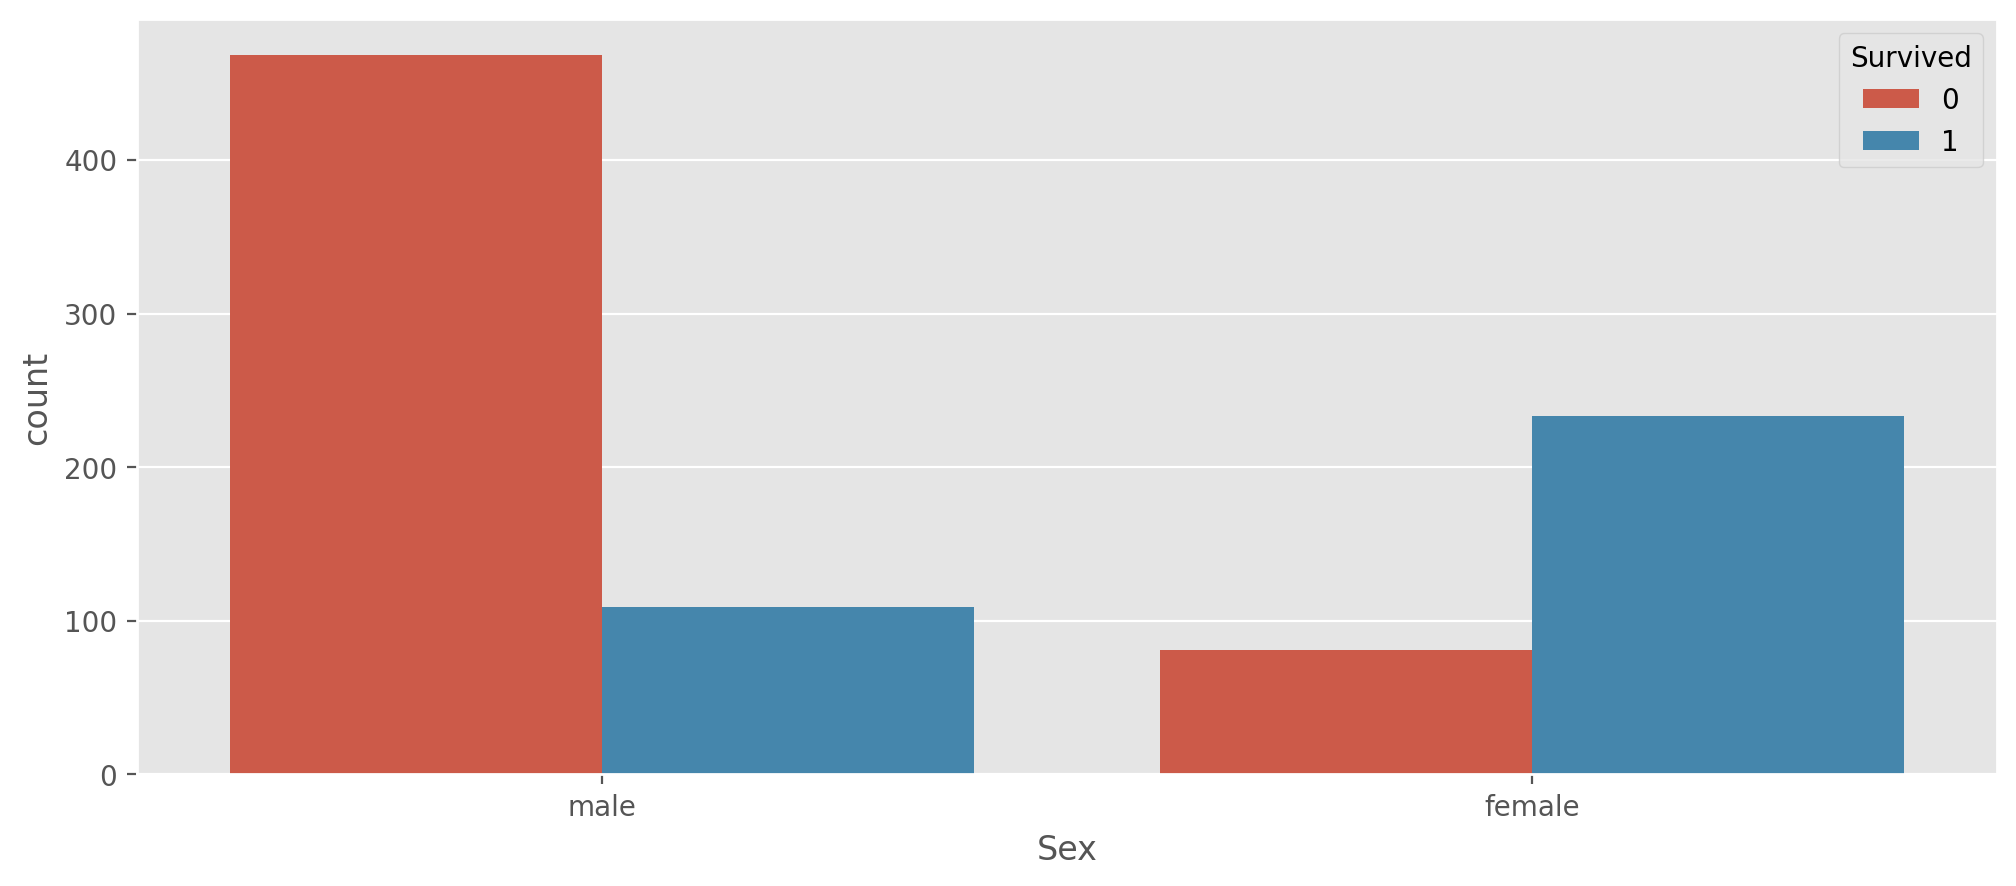

In [51]:
# Analysing Survival with Gender
plt.figure(figsize = (12,5), dpi = 200)
sns.countplot('Sex', hue = 'Survived', data = titanic)

In [40]:
svl_rate = titanic.groupby('Sex')['Survived'].value_counts(normalize = True)
svl_rate

Sex     Survived
female  1           0.742038
        0           0.257962
male    0           0.811092
        1           0.188908
Name: Survived, dtype: float64

In [44]:
print('Percentage of female survivors  : ', round(svl_rate['female'][1]*100,2), '%')
print('Percentage of dead females      : ', round(svl_rate['female'][0]*100, 2), '%')
print('Percentage of male survivors    : ', round(svl_rate['male'][1]*100, 2), '%')
print('Percentage of dead males        : ', round(svl_rate['male'][0]*100, 2), '%')

Percentage of female survivors  :  74.2 %
Percentage of dead females      :  25.8 %
Percentage of male survivors    :  18.89 %
Percentage of dead males        :  81.11 %


<AxesSubplot:xlabel='Pclass', ylabel='count'>

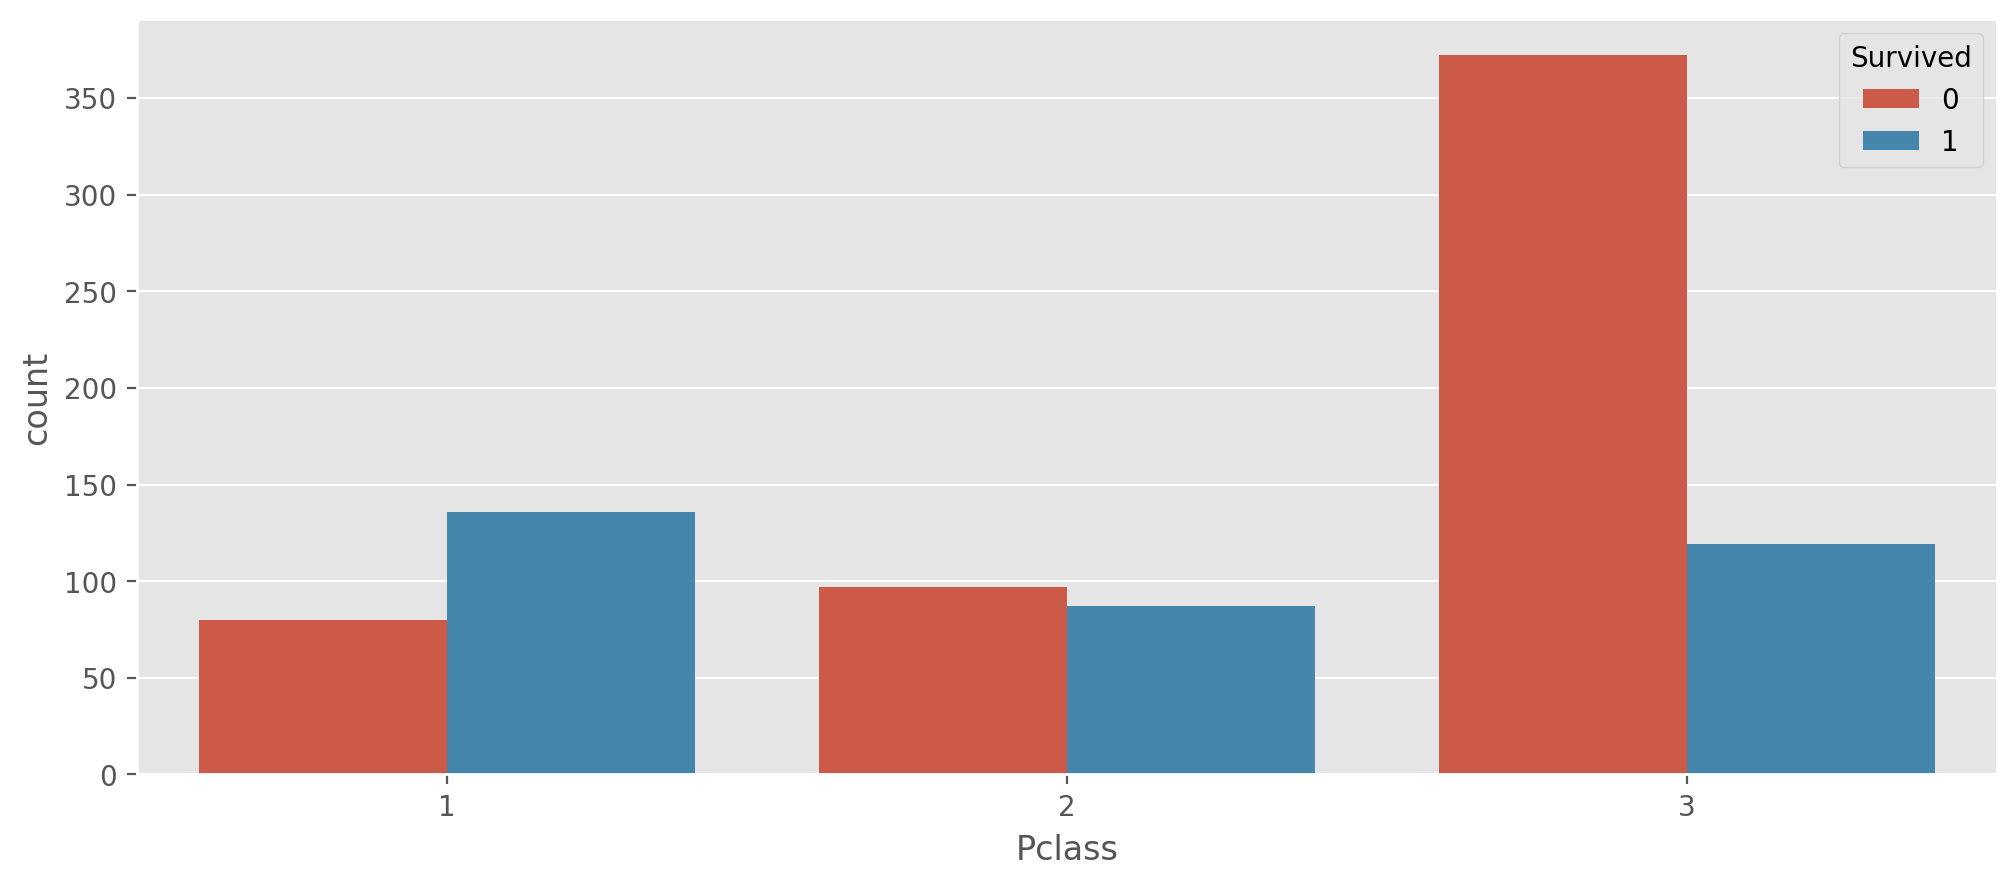

In [52]:
# Survival with respect to passenger class
plt.figure(figsize = (12,5), dpi = 200)
sns.countplot('Pclass', hue = 'Survived', data = titanic)

In [56]:
svl_rate = titanic.groupby('Pclass')['Survived'].value_counts(normalize = True)
svl_rate

Pclass  Survived
1       1           0.629630
        0           0.370370
2       0           0.527174
        1           0.472826
3       0           0.757637
        1           0.242363
Name: Survived, dtype: float64

In [57]:
print('Percentage of 1st Passenger class Survivors : ', round(svl_rate[1][1]*100,2), '%')
print('Percentage of 1st Passenger class Dead      : ', round(svl_rate[1][0]*100,2), '%')
print('Percentage of 2nd Passenger class Survivors : ', round(svl_rate[2][1]*100,2), '%')
print('Percentage of 2nd Passenger class Dead      : ', round(svl_rate[2][0]*100,2), '%')
print('Percentage of 3rd Passenger class Survivors : ', round(svl_rate[3][1]*100,2), '%')
print('Percentage of 3rd Passenger class Dead      : ', round(svl_rate[3][0]*100,2), '%')

Percentage of 1st Passenger class Survivors :  62.96 %
Percentage of 1st Passenger class Dead      :  37.04 %
Percentage of 2nd Passenger class Survivors :  47.28 %
Percentage of 2nd Passenger class Dead      :  52.72 %
Percentage of 3rd Passenger class Survivors :  24.24 %
Percentage of 3rd Passenger class Dead      :  75.76 %


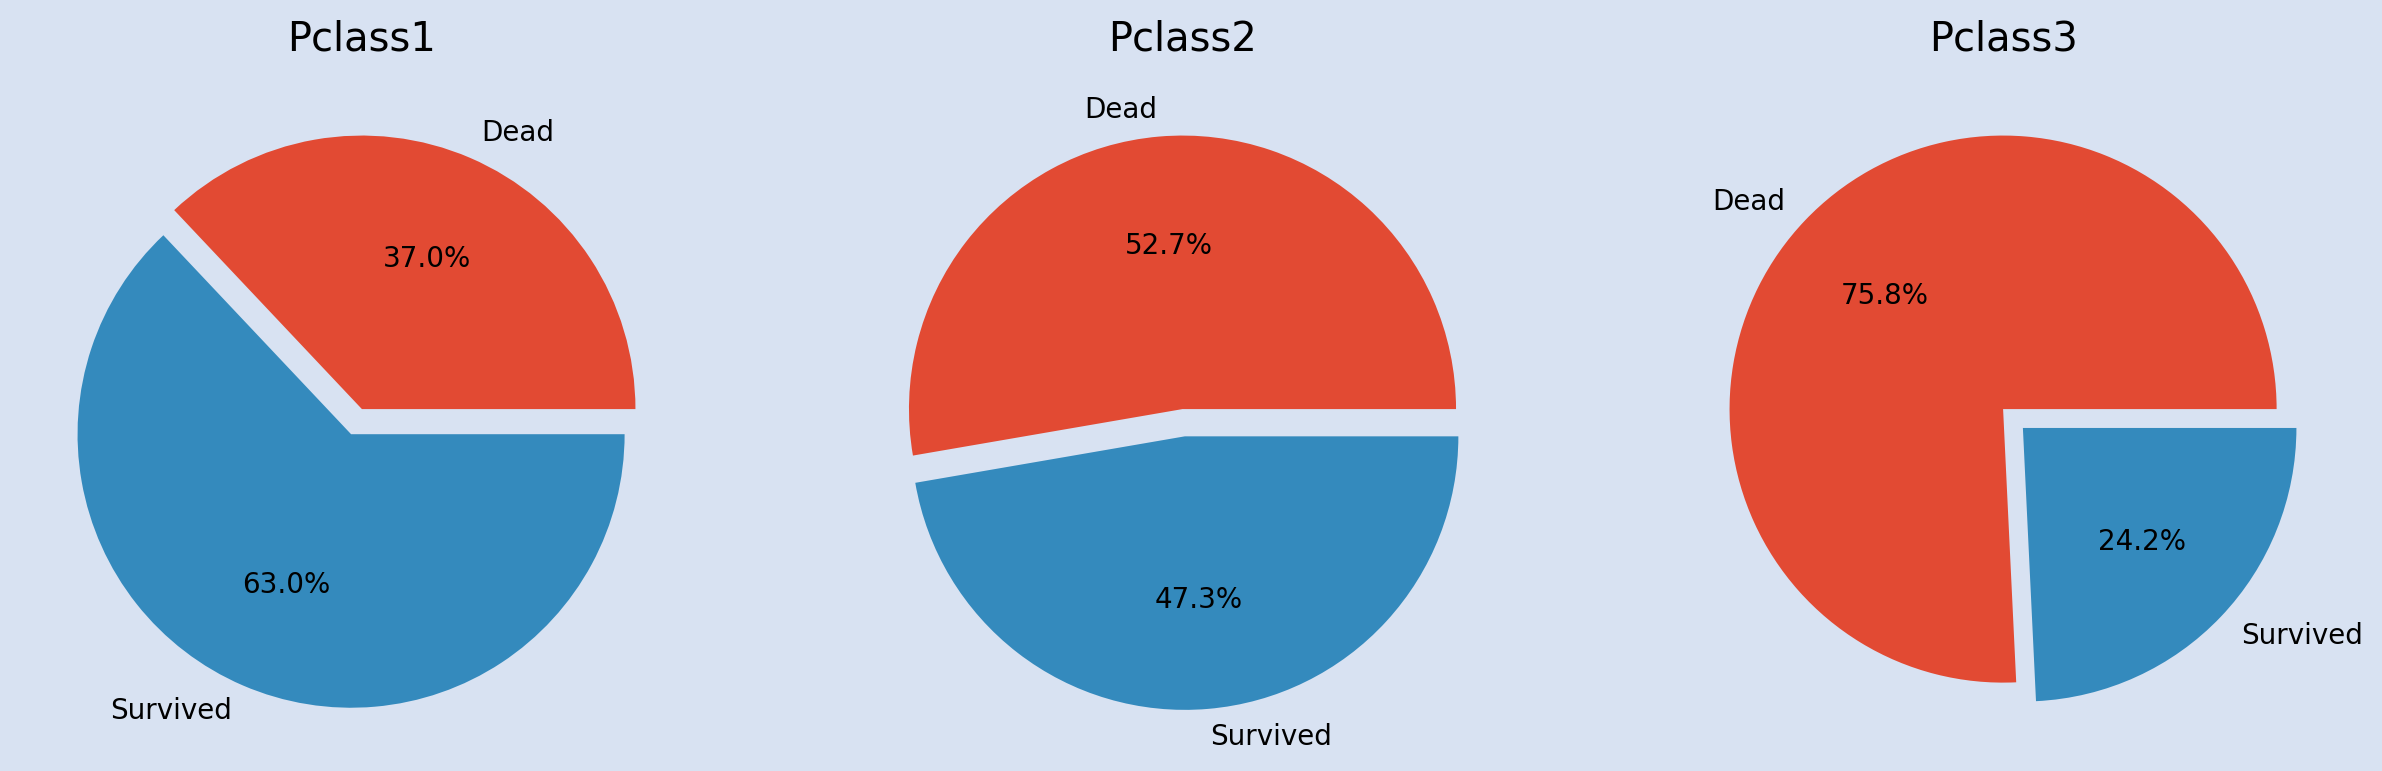

In [77]:
svl_rate.sort_index(inplace = True)
pclass1 = svl_rate[1]
pclass2 = svl_rate[2]
pclass3 = svl_rate[3]

labels = ['Dead', 'Survived']

plt.figure(figsize= (15,5), dpi = 200,  facecolor = '#d8e2f2')
plt.subplot(1,3,1)
plt.pie(pclass1, labels = labels, autopct = '%1.1f%%', explode = [0, 0.1])
plt.title('Pclass1')
plt.subplot(1,3,2)
plt.pie(pclass2, labels = labels, autopct = '%1.1f%%', explode = [0, 0.1])
plt.title('Pclass2')
plt.subplot(1,3,3)
plt.pie(pclass3, labels = labels, autopct = '%1.1f%%', explode = [0, 0.1])
plt.title('Pclass3')
plt.show()

<AxesSubplot:xlabel='Embarked', ylabel='count'>

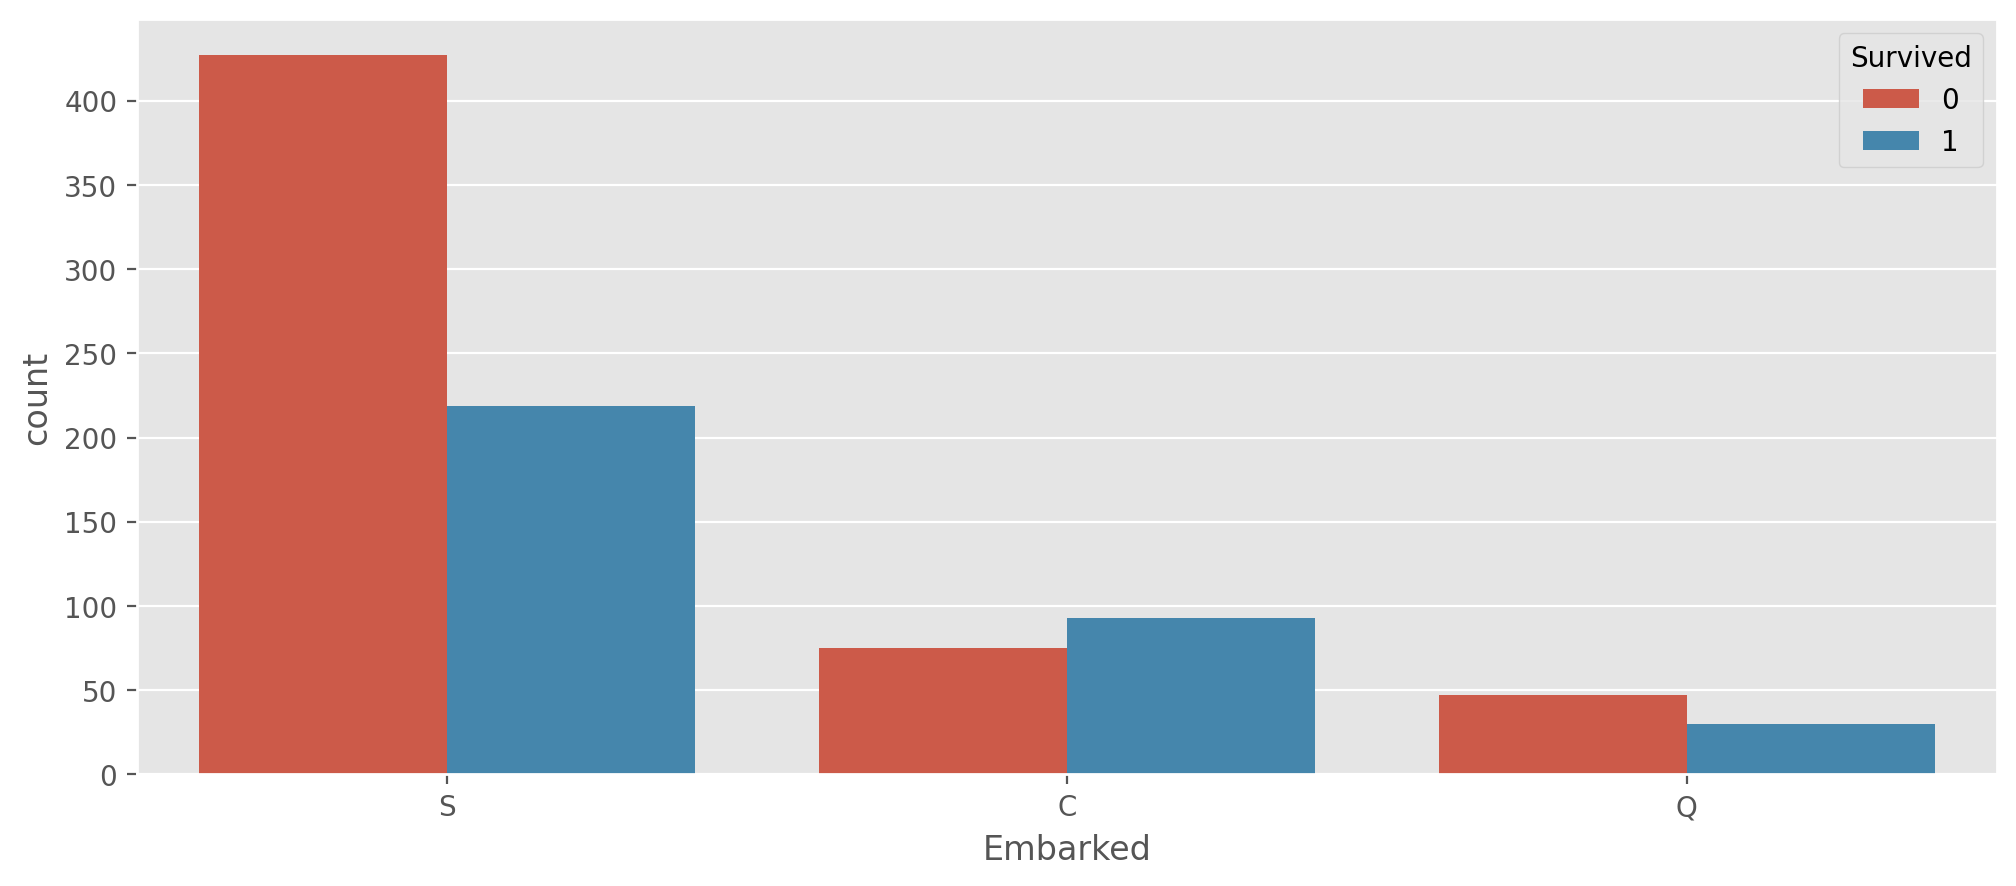

In [78]:
# Survival with respect to Embarked
plt.figure(figsize = (12,5), dpi = 200)
sns.countplot('Embarked', hue = 'Survived', data = titanic)

In [79]:
svl_rate = titanic.groupby('Embarked')['Survived'].value_counts(normalize = True)
svl_rate

Embarked  Survived
C         1           0.553571
          0           0.446429
Q         0           0.610390
          1           0.389610
S         0           0.660991
          1           0.339009
Name: Survived, dtype: float64

<AxesSubplot:ylabel='Fare'>

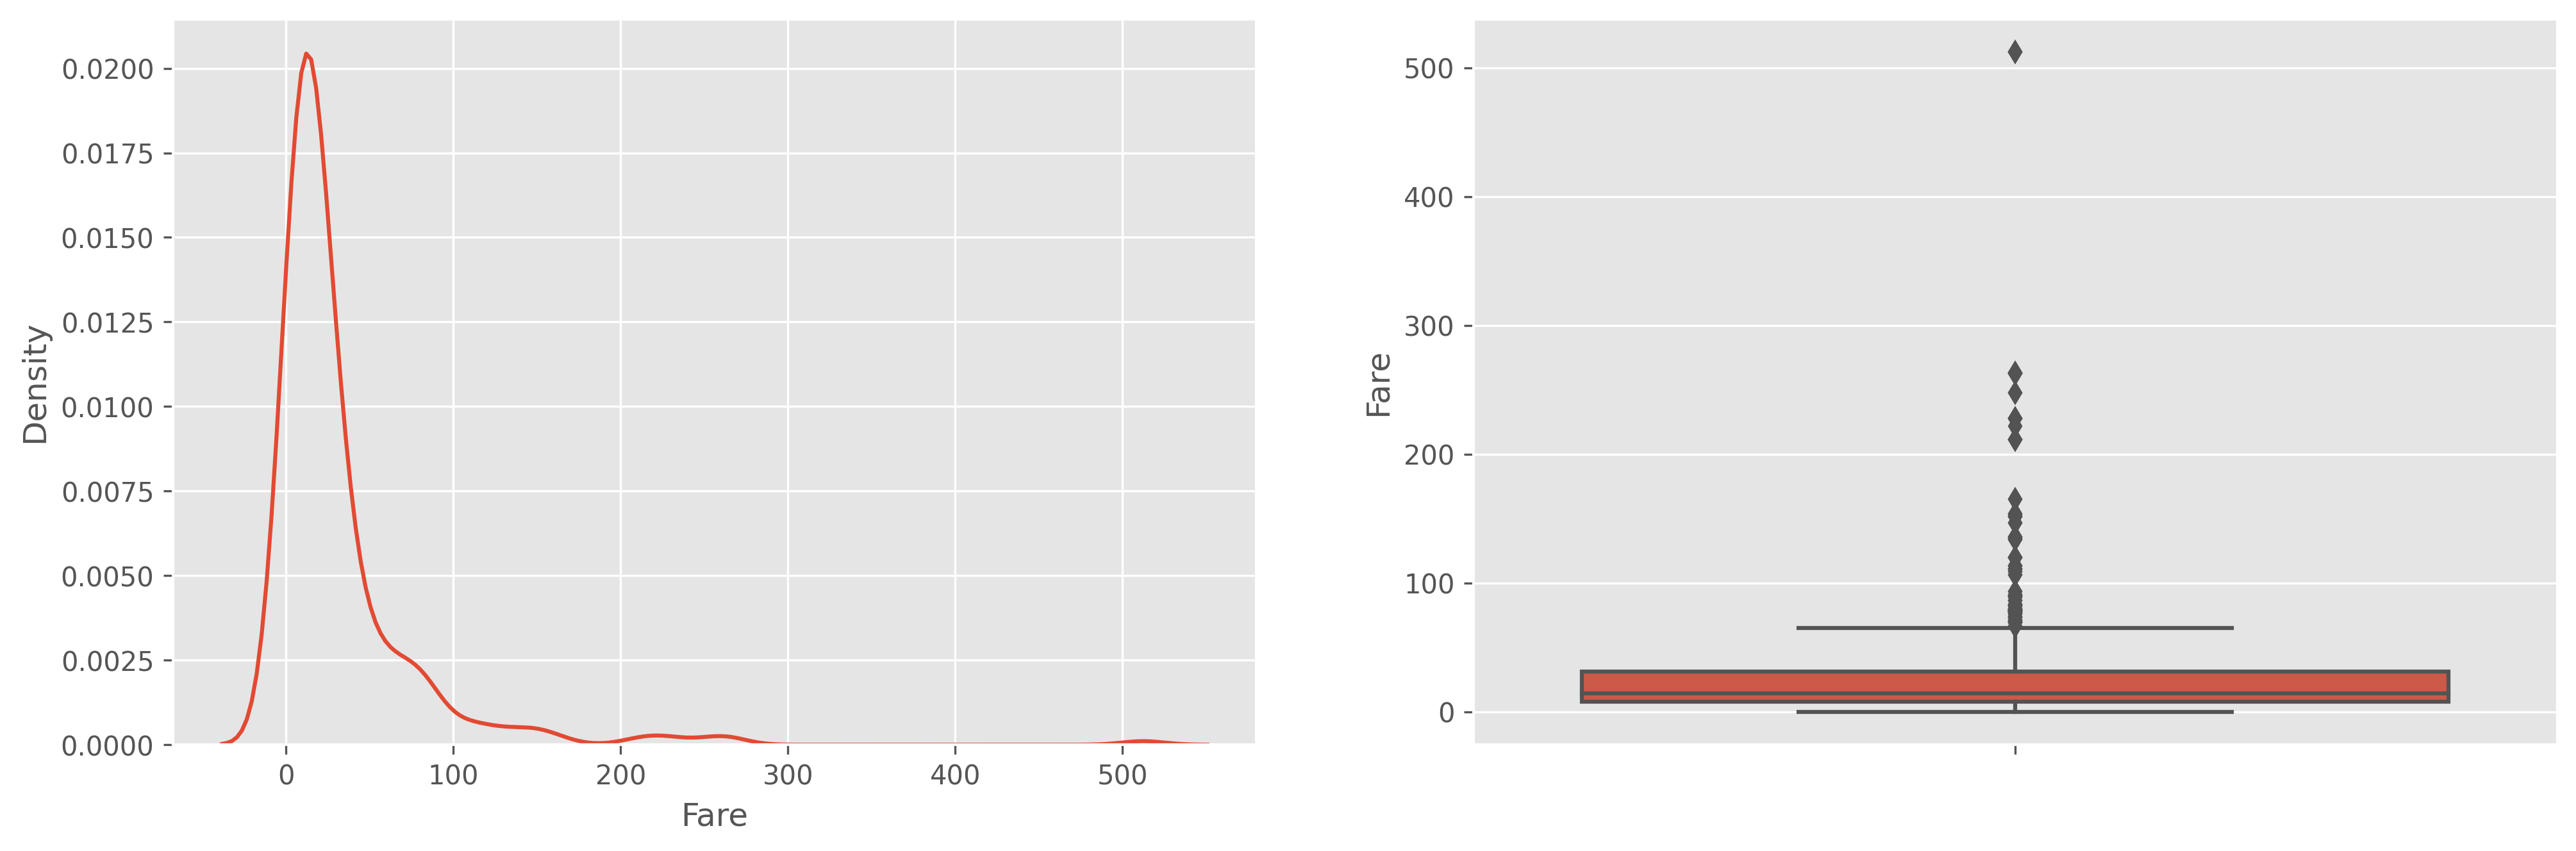

In [81]:
# Analysing fare
plt.figure(figsize = (16,5), dpi = 300)
plt.subplot(1,2,1)
sns.distplot(titanic.Fare, hist = False)
plt.subplot(1,2,2)
sns.boxplot(y = 'Fare', data = titanic)

In [83]:
titanic[titanic.Fare > 500]

,PassengerId,Survived,Pclass,Name,Sex,Age,Ticket,Fare,Embarked,family_members
258,259,1,1,"Ward, Miss. Anna",female,35.0,PC 17755,512.3292,C,0
679,680,1,1,"Cardeza, Mr. Thomas Drake Martinez",male,36.0,PC 17755,512.3292,C,1
737,738,1,1,"Lesurer, Mr. Gustave J",male,35.0,PC 17755,512.3292,C,0


<AxesSubplot:xlabel='Survived', ylabel='Fare'>

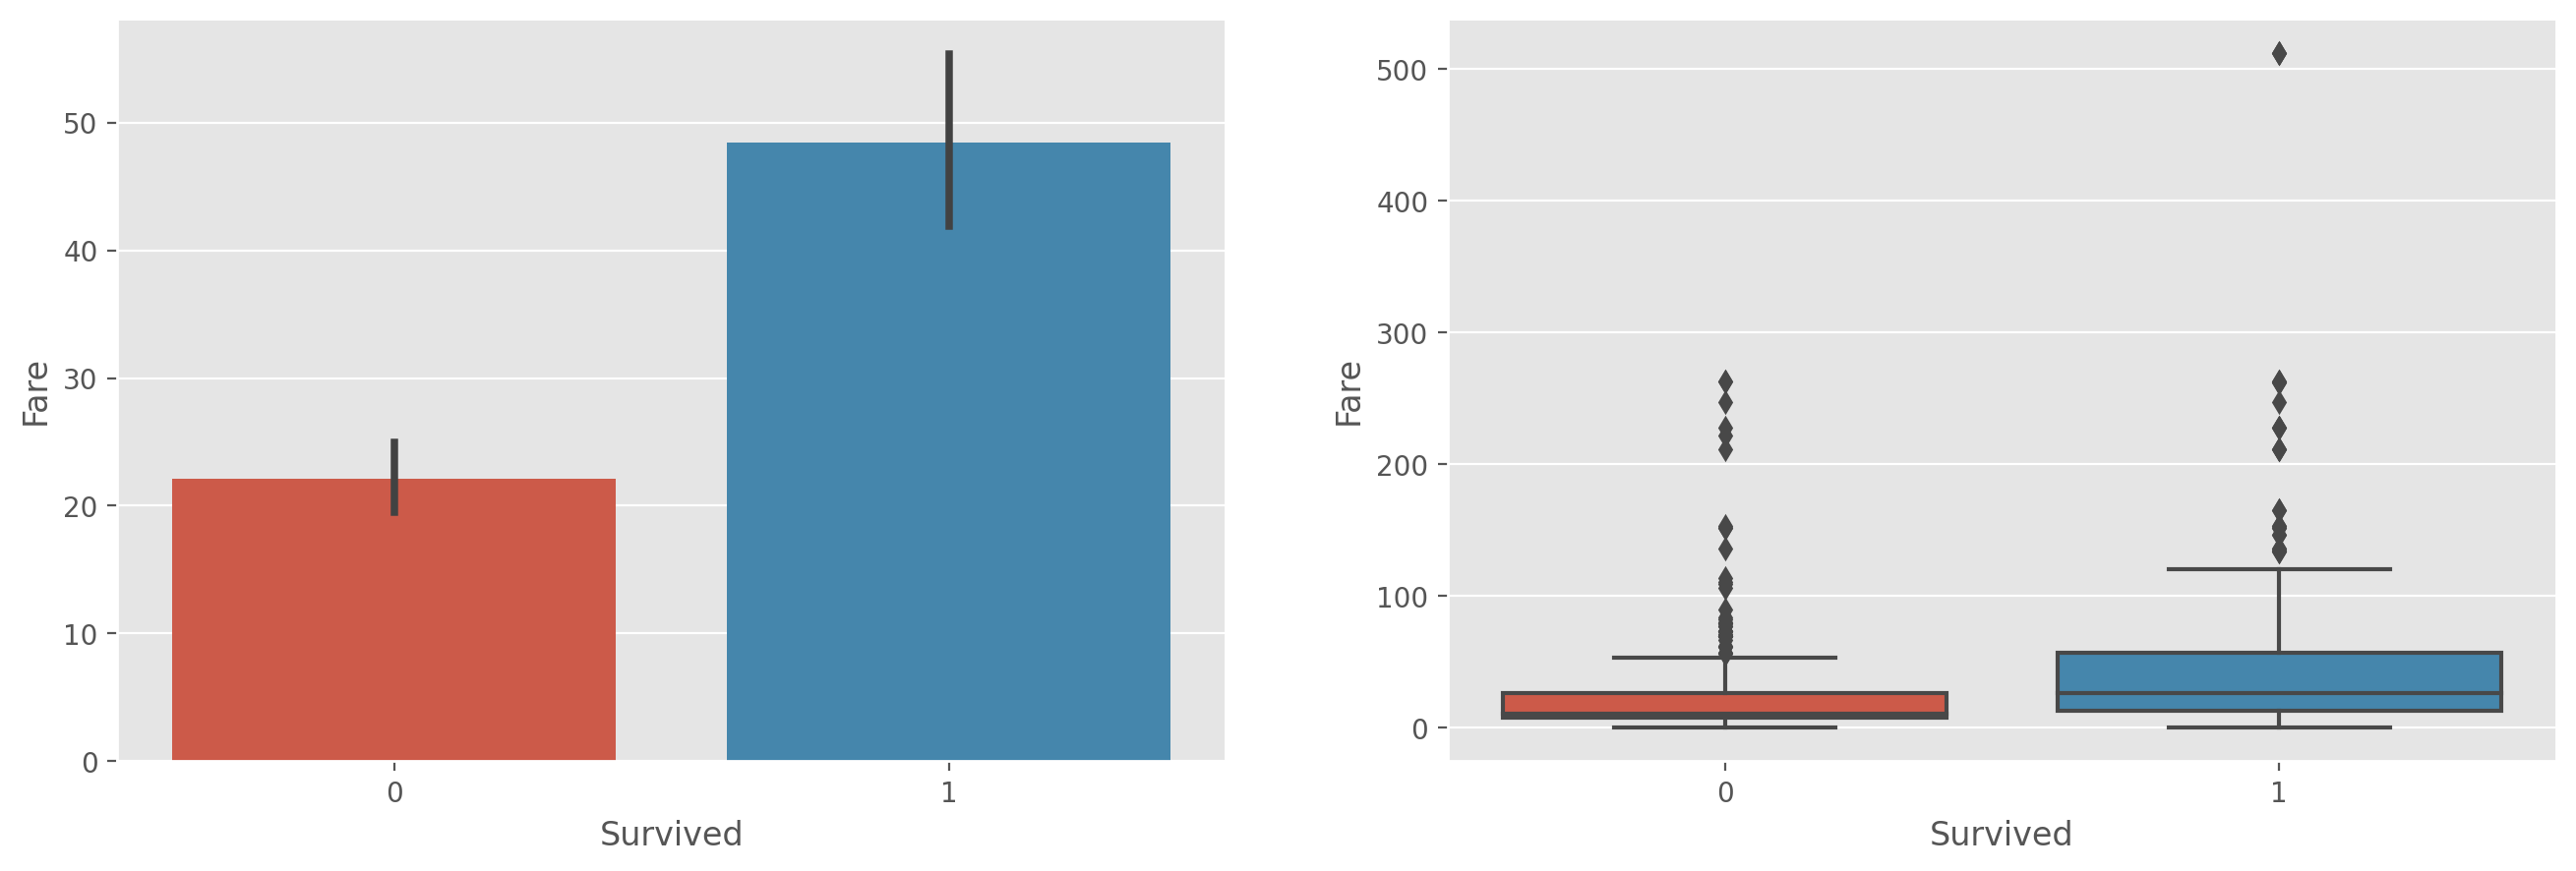

In [84]:
# Analysing fare wrt Pclass
plt.figure(figsize = (16,5), dpi = 200)
plt.subplot(1,2,1)
sns.barplot('Survived', 'Fare', data = titanic)
plt.subplot(1,2,2)
sns.boxplot('Survived', 'Fare', data = titanic)

<AxesSubplot:xlabel='Pclass', ylabel='Fare'>

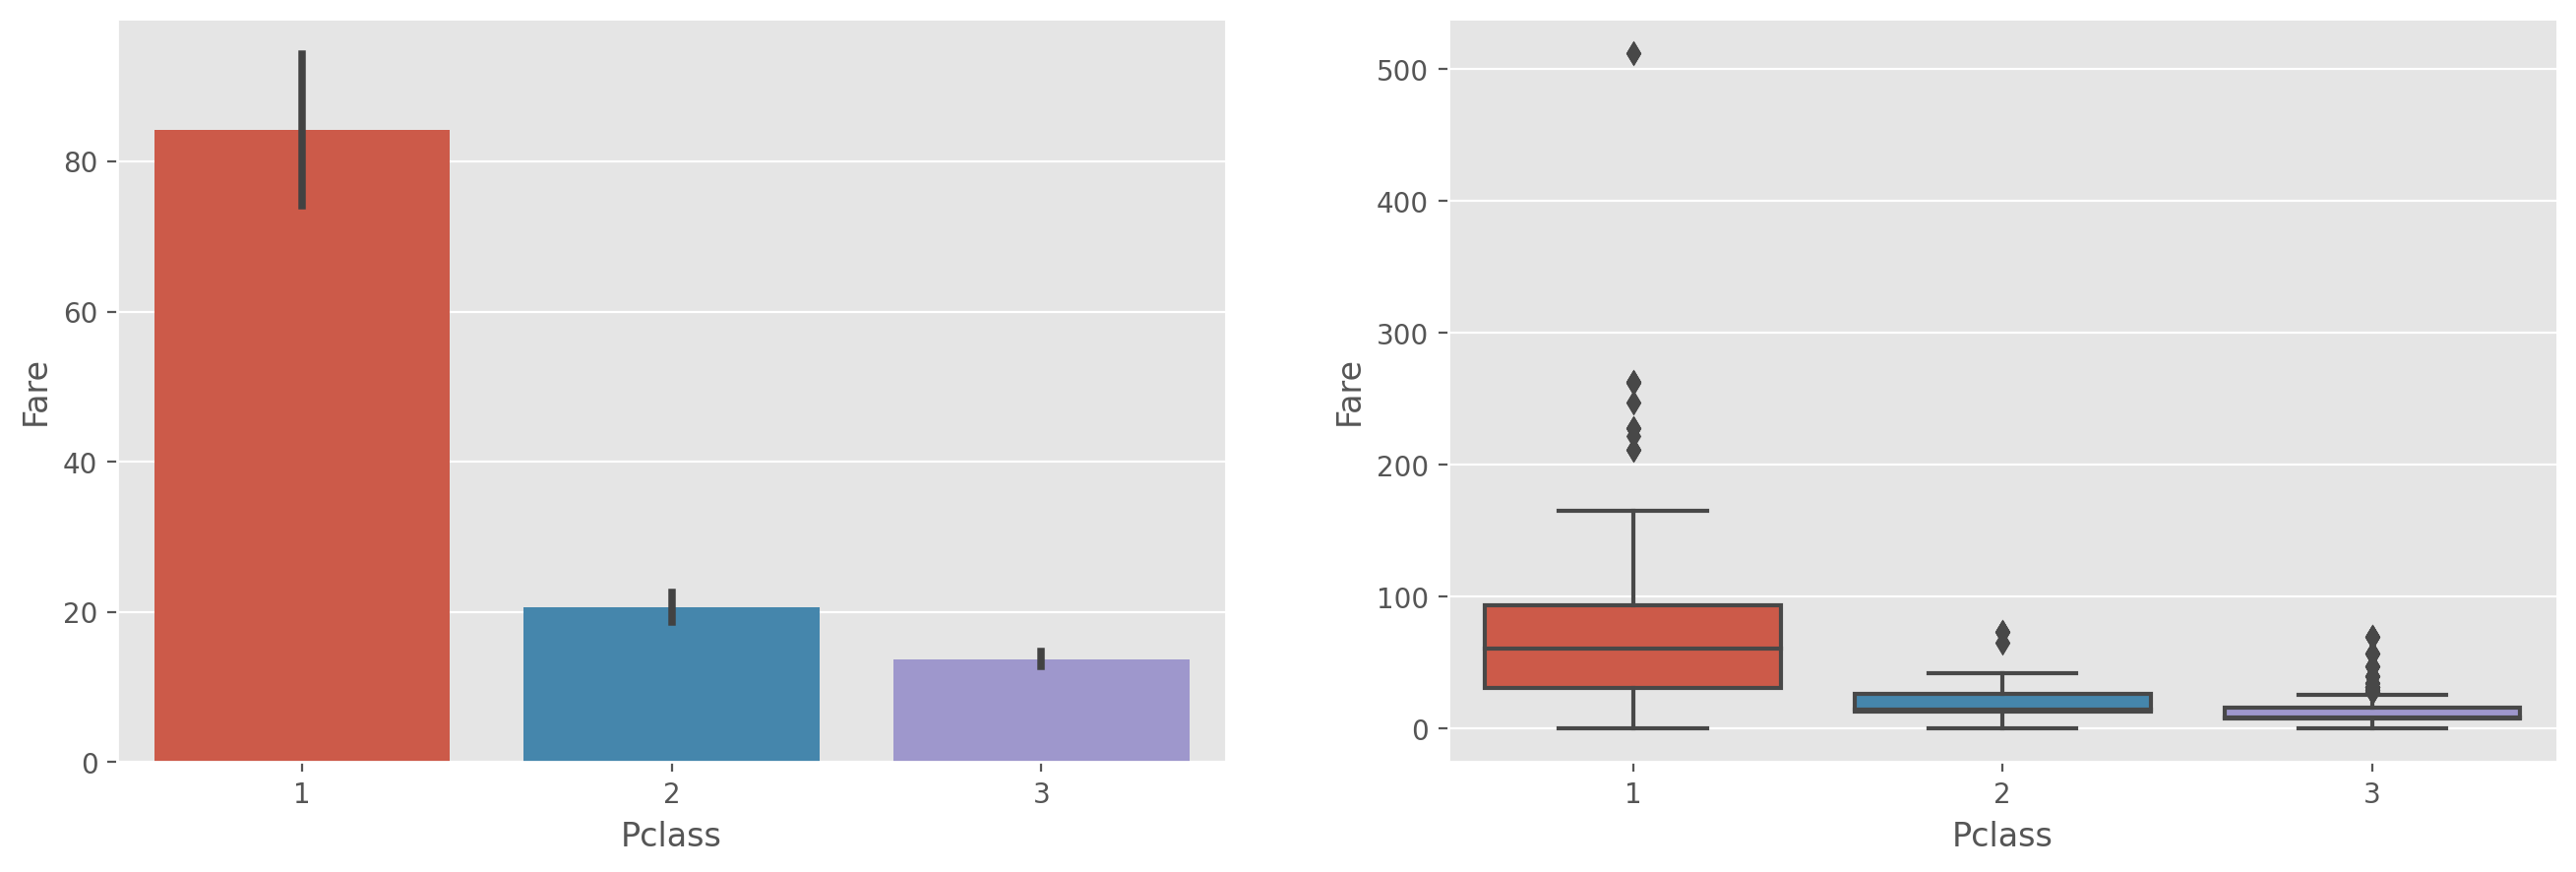

In [85]:
# Analysing fare wrt Pclass
plt.figure(figsize = (16,5), dpi = 200)
plt.subplot(1,2,1)
sns.barplot('Pclass', 'Fare', data = titanic)
plt.subplot(1,2,2)
sns.boxplot('Pclass', 'Fare', data = titanic)

<AxesSubplot:xlabel='Sex', ylabel='Fare'>

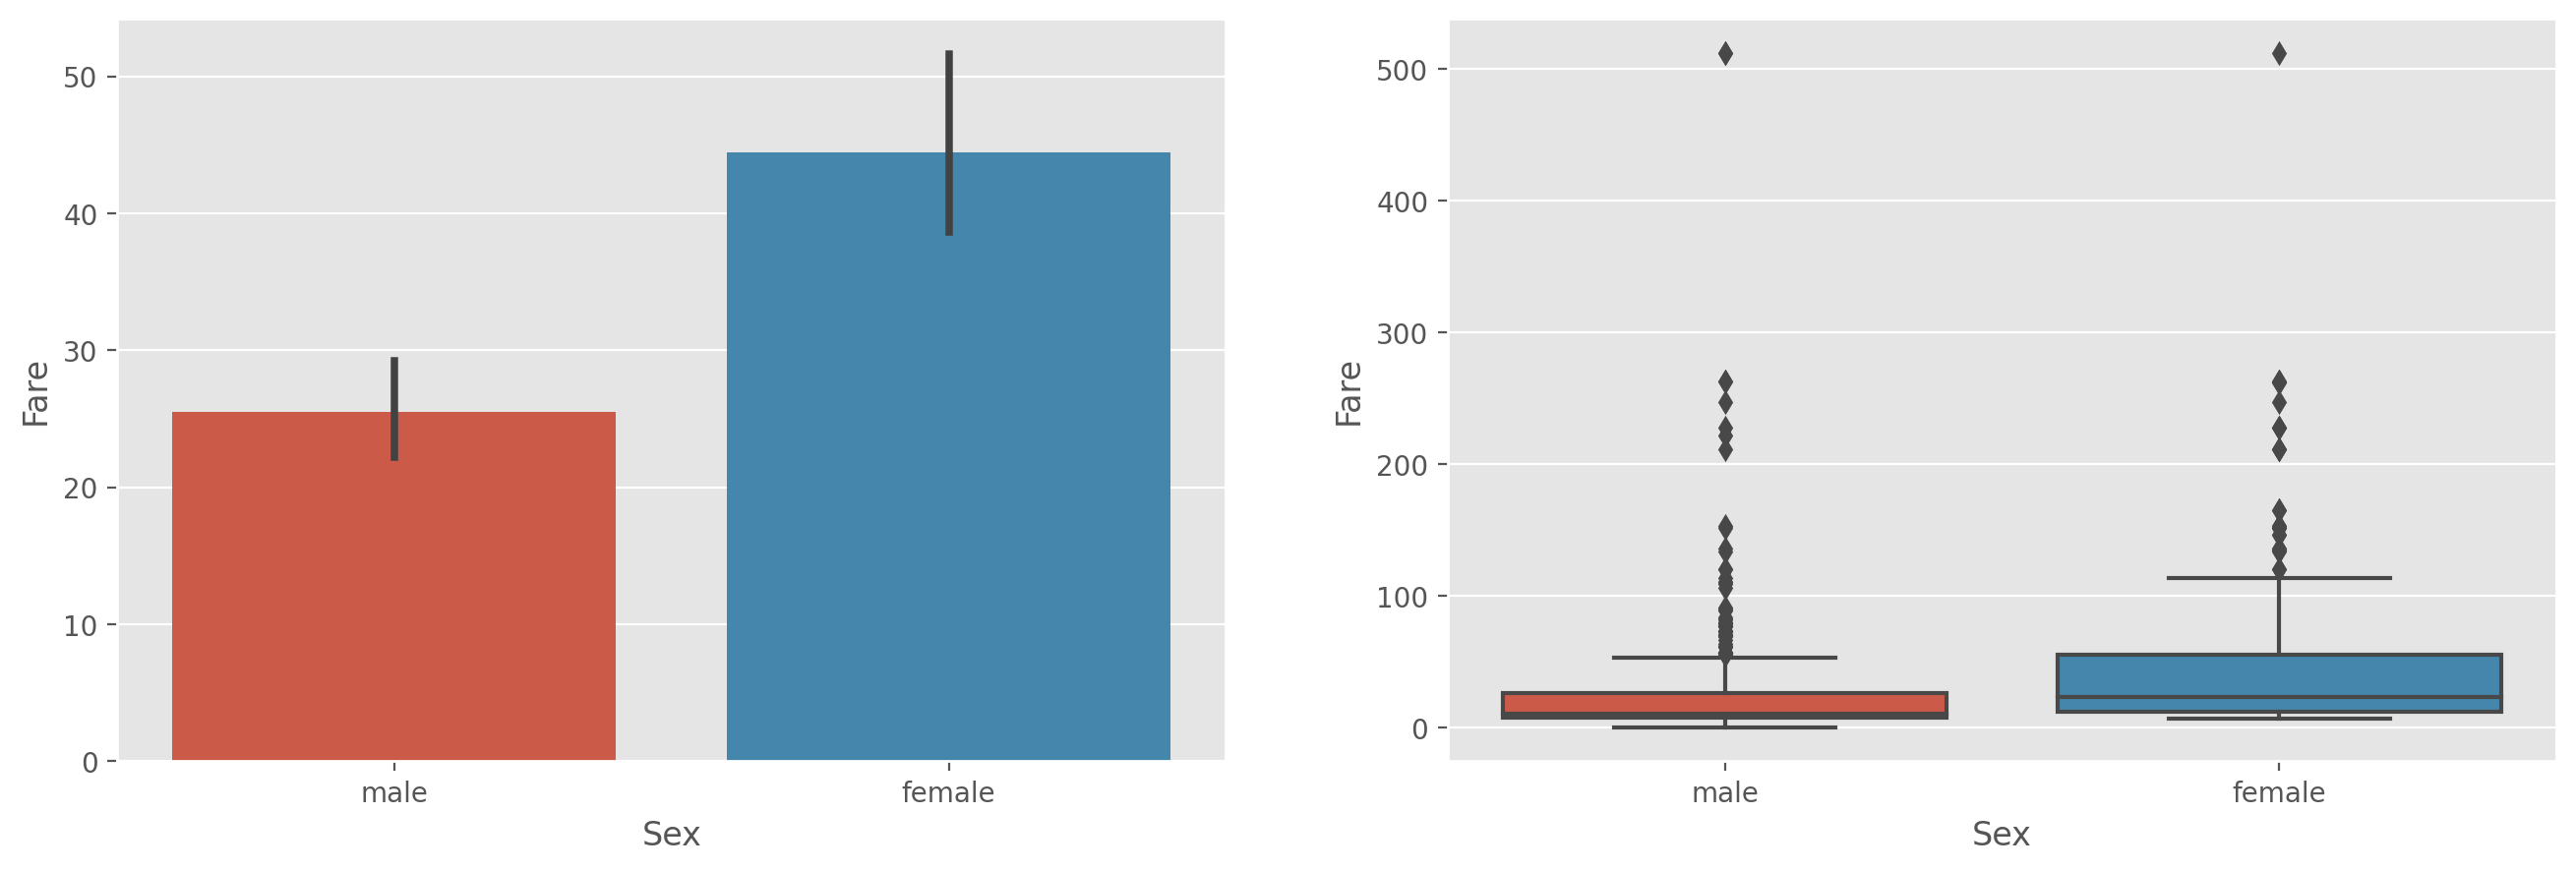

In [86]:
# Analysing fare wrt Pclass
plt.figure(figsize = (16,5), dpi = 200)
plt.subplot(1,2,1)
sns.barplot('Sex', 'Fare', data = titanic)
plt.subplot(1,2,2)
sns.boxplot('Sex', 'Fare', data = titanic)

In [9]:
titanic.Fare.mean()

32.204207968574636

<AxesSubplot:xlabel='Embarked', ylabel='Fare'>

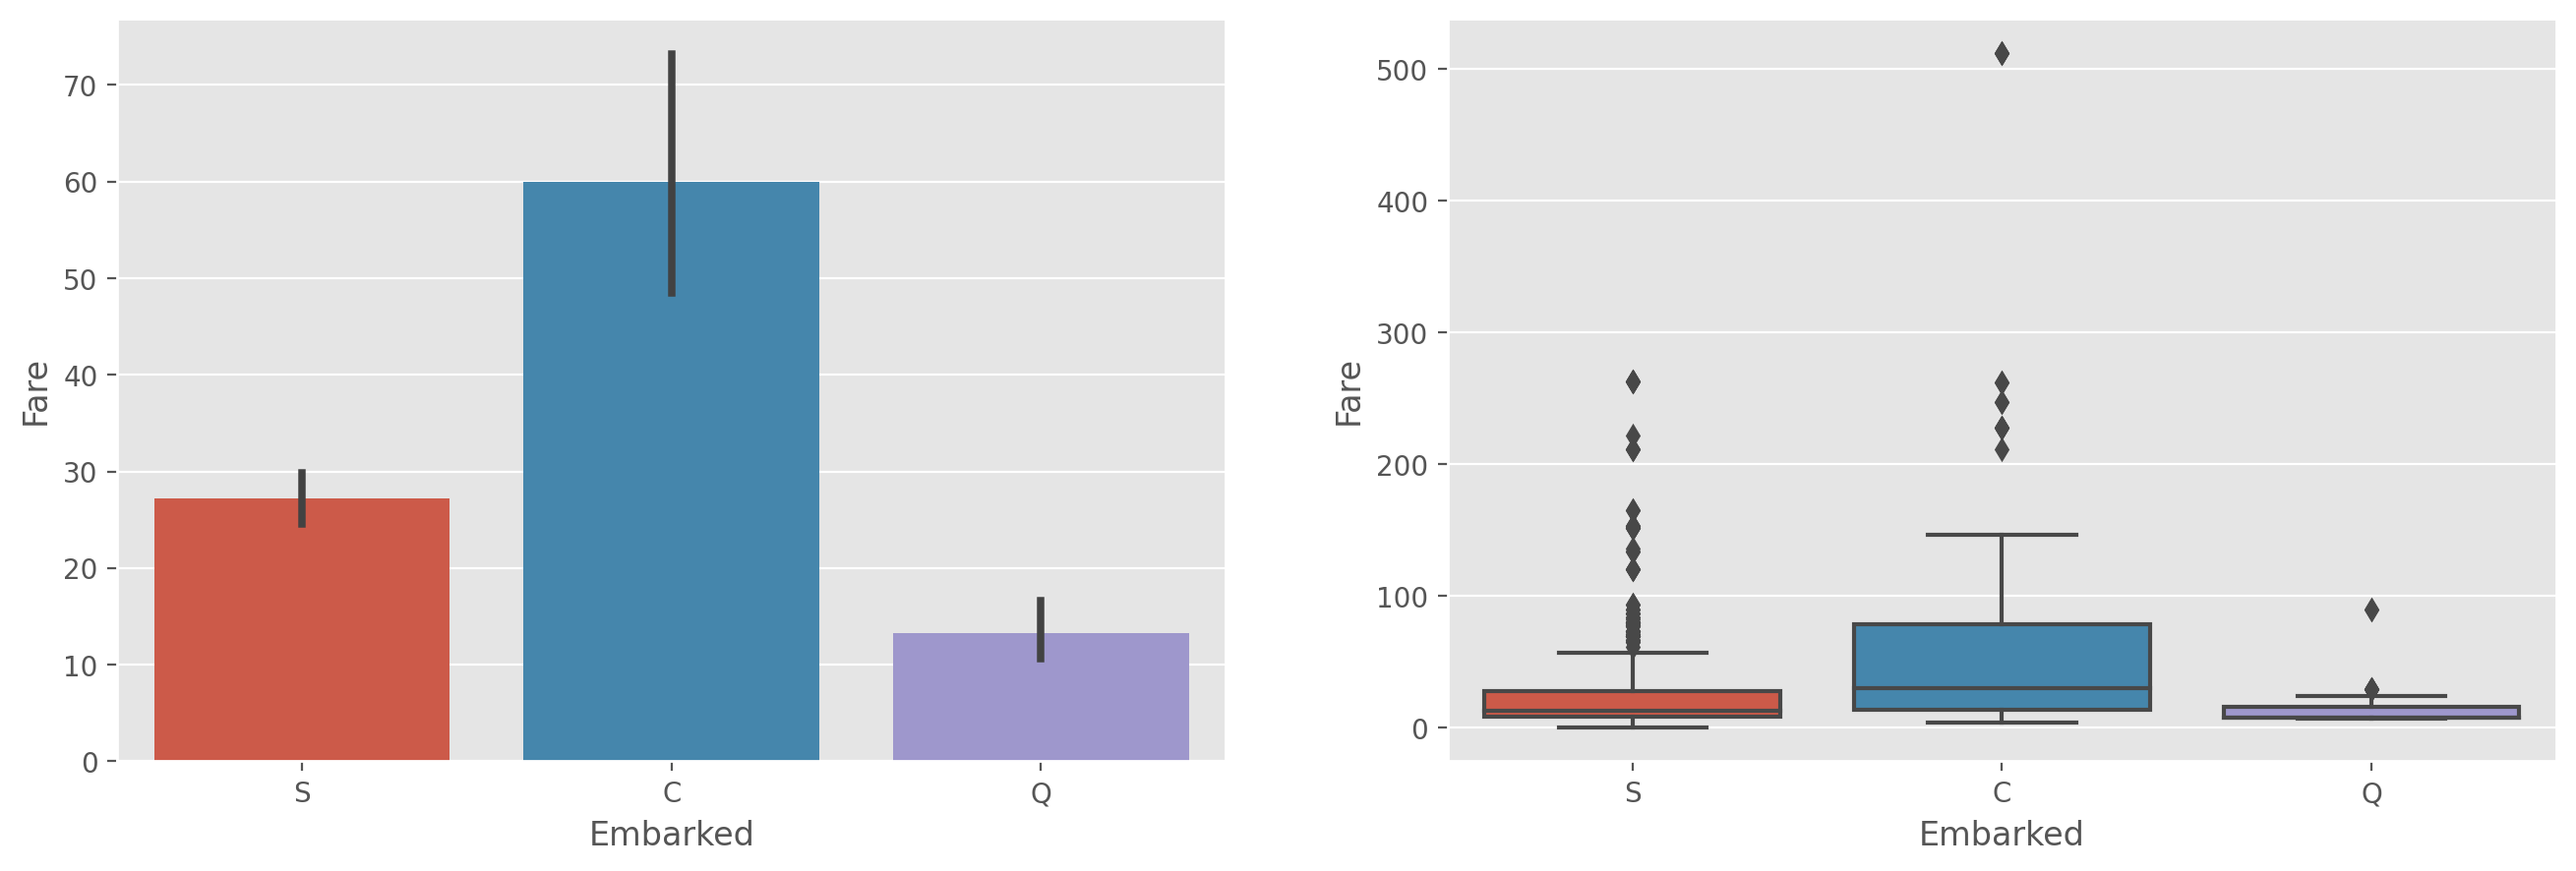

In [87]:
# Analysing fare wrt Pclass
plt.figure(figsize = (16,5), dpi = 200)
plt.subplot(1,2,1)
sns.barplot('Embarked', 'Fare', data = titanic)
plt.subplot(1,2,2)
sns.boxplot('Embarked', 'Fare', data = titanic)

<AxesSubplot:xlabel='Sex', ylabel='Fare'>

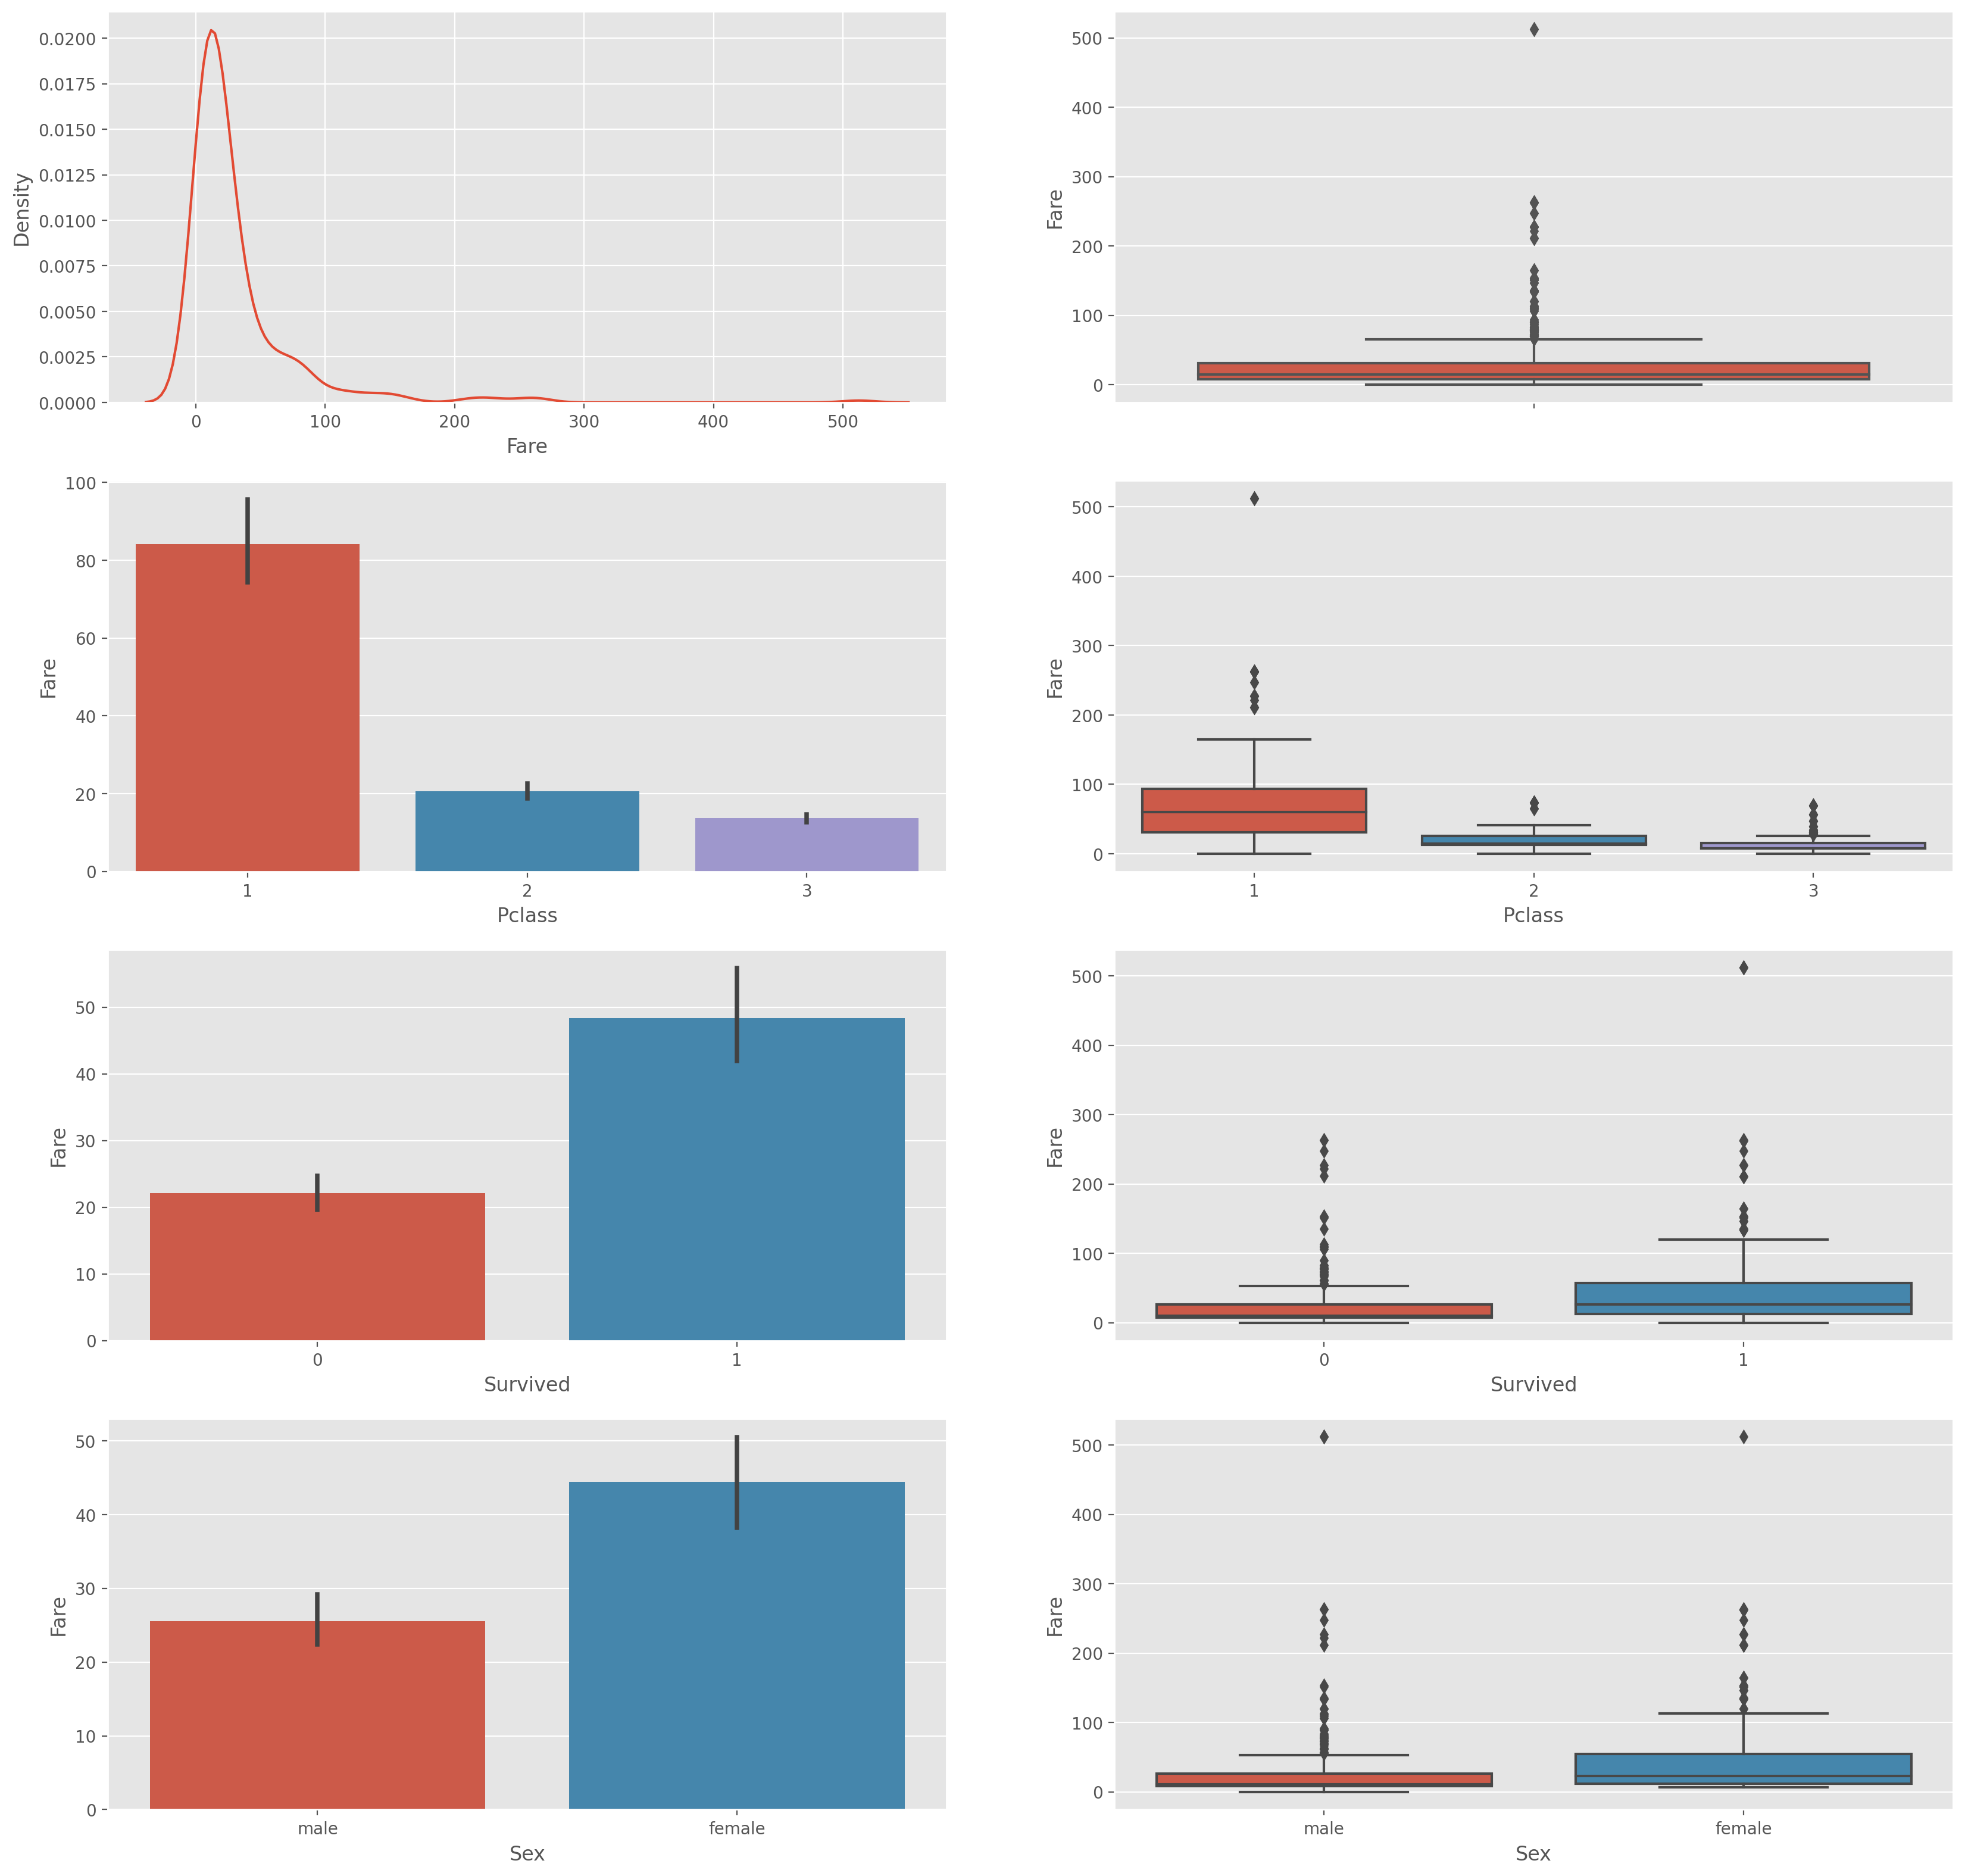

In [88]:
# Analysing fare
plt.figure(figsize = (20,20), dpi = 200)
plt.subplot(4,2,1)
sns.distplot(titanic.Fare, hist = False)
plt.subplot(4,2,2)
sns.boxplot(y = 'Fare', data = titanic)
plt.subplot(4,2,3)
sns.barplot('Pclass', 'Fare', data = titanic)
plt.subplot(4,2,4)
sns.boxplot('Pclass', 'Fare', data = titanic)
plt.subplot(4,2,5)
sns.barplot('Survived', 'Fare', data = titanic)
plt.subplot(4,2,6)
sns.boxplot('Survived', 'Fare', data = titanic)
plt.subplot(4,2,7)
sns.barplot('Sex', 'Fare', data = titanic)
plt.subplot(4,2,8)
sns.boxplot('Sex', 'Fare', data = titanic)

<AxesSubplot:xlabel='Sex', ylabel='Age'>

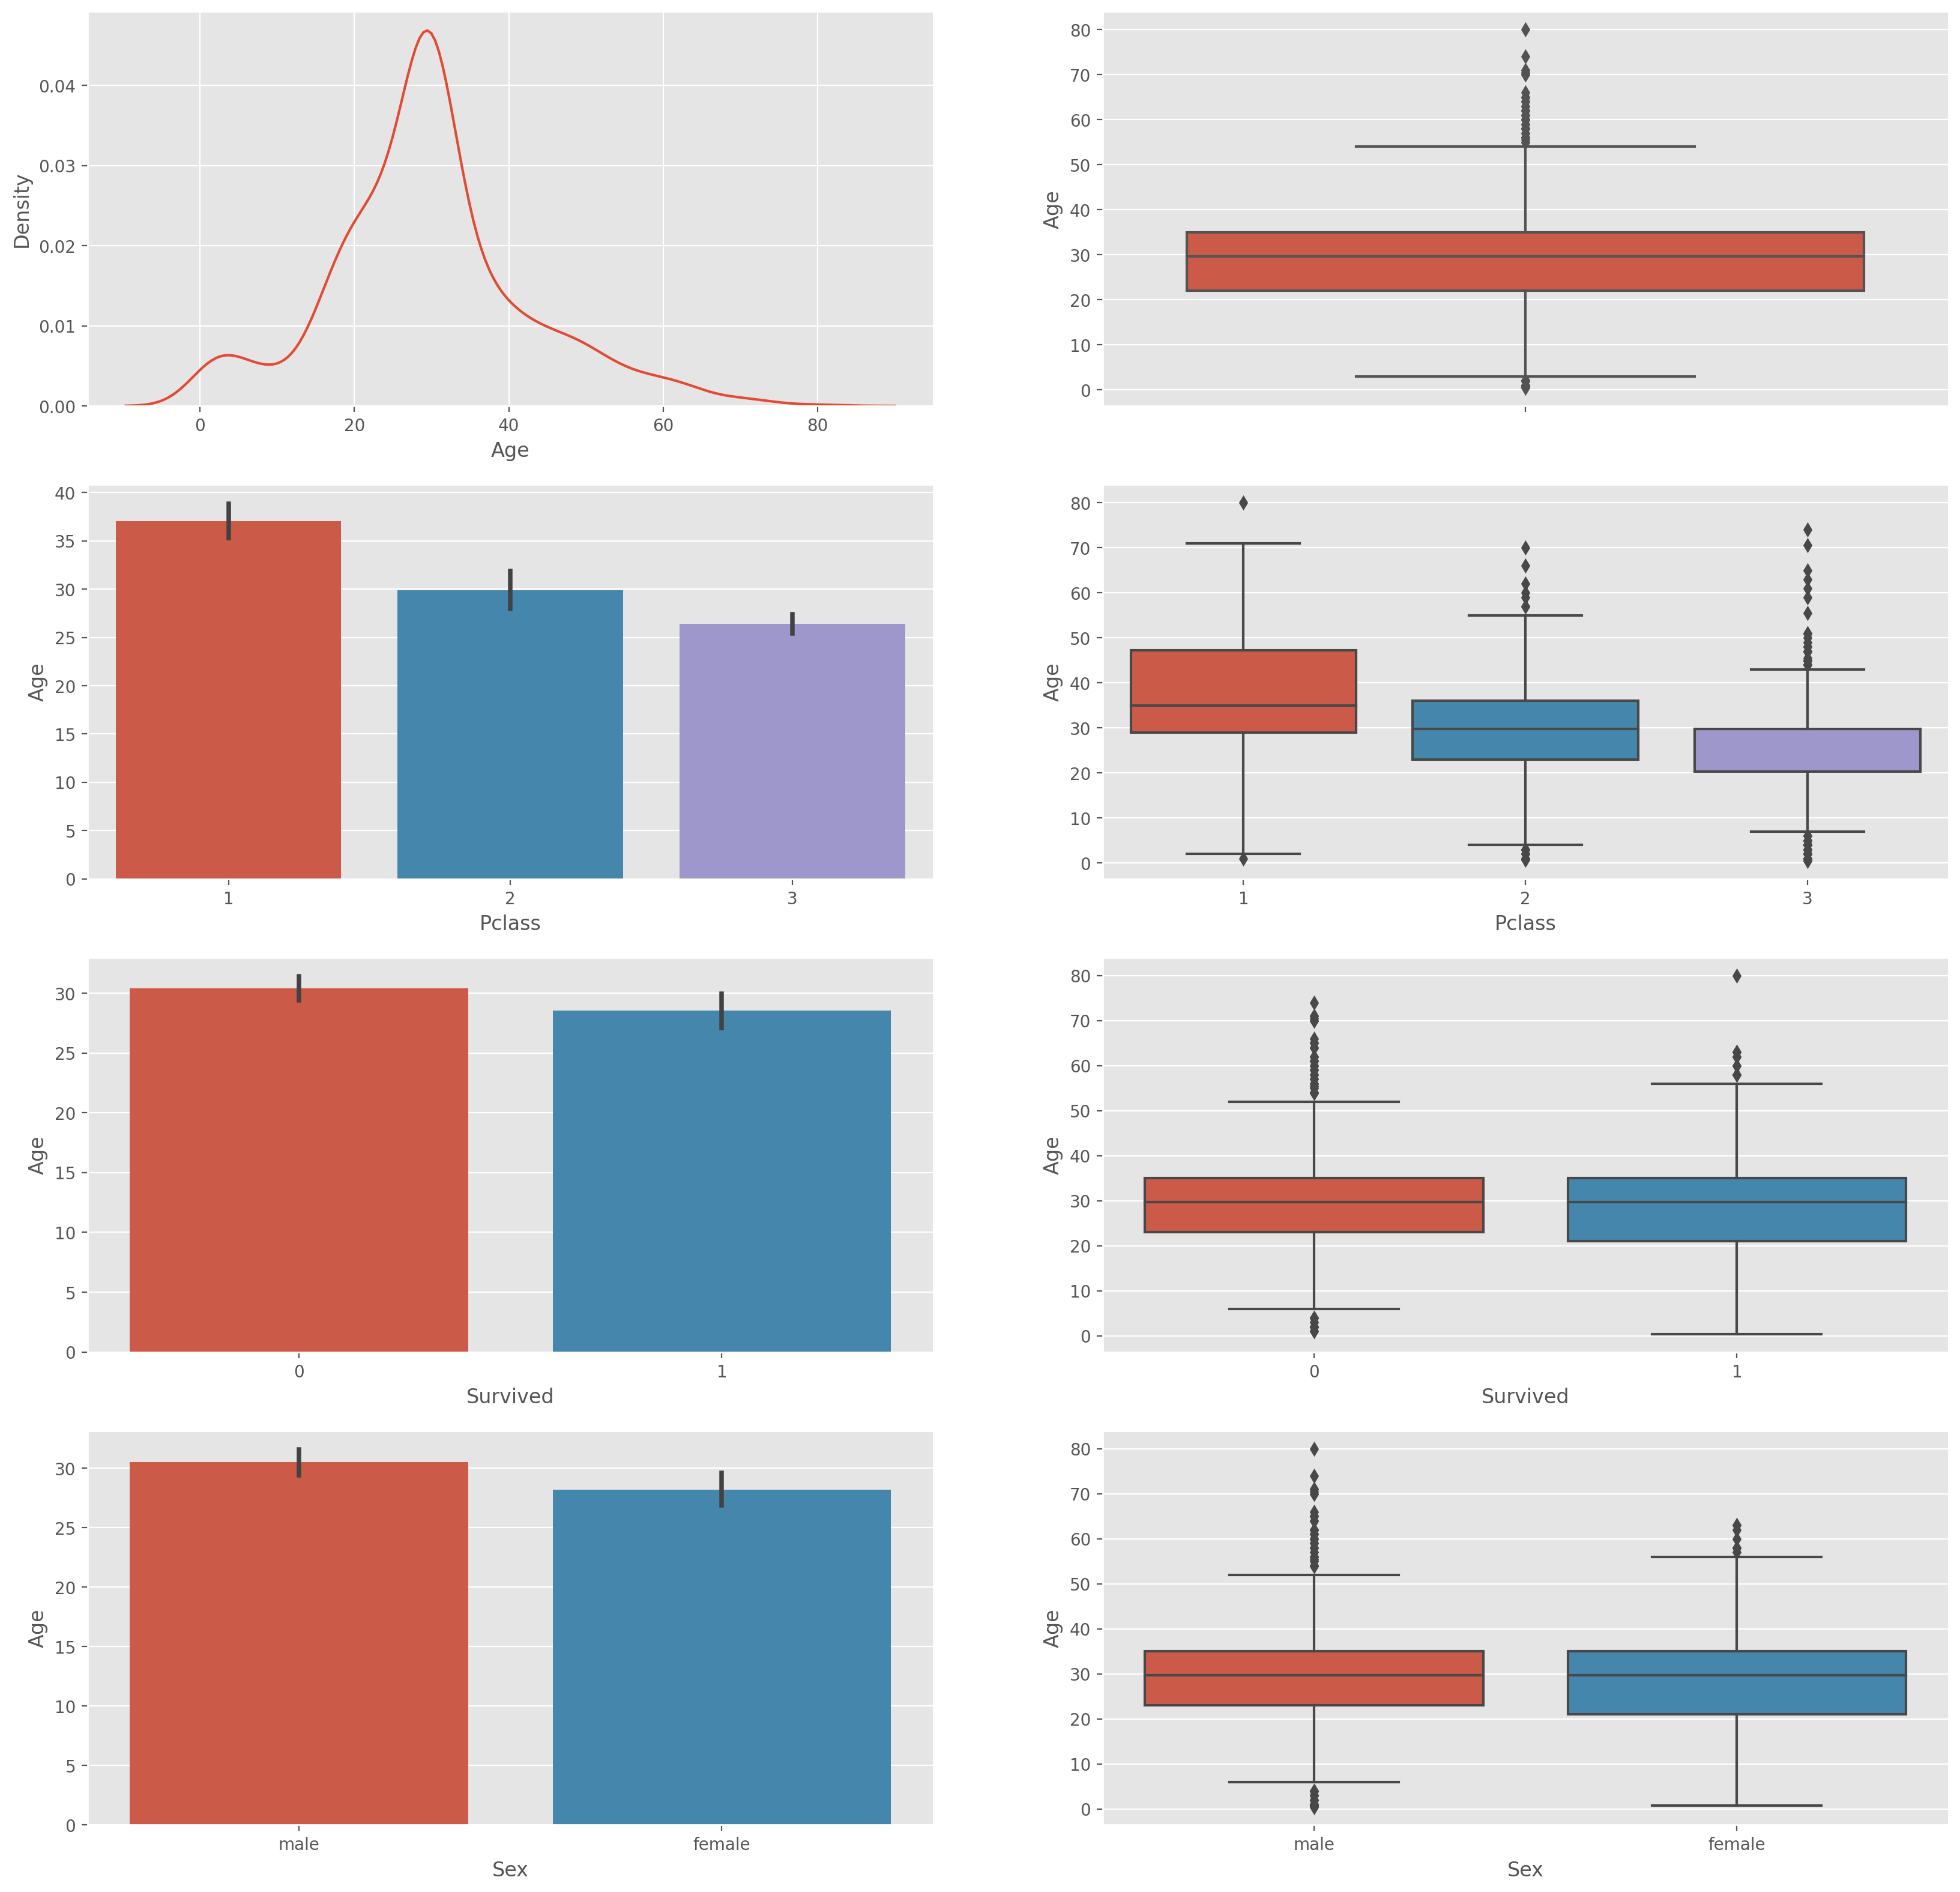

In [89]:
# Analysing fare
plt.figure(figsize = (20,20), dpi = 200)
plt.subplot(4,2,1)
sns.distplot(titanic.Age, hist = False)
plt.subplot(4,2,2)
sns.boxplot(y = 'Age', data = titanic)
plt.subplot(4,2,3)
sns.barplot('Pclass', 'Age', data = titanic)
plt.subplot(4,2,4)
sns.boxplot('Pclass', 'Age', data = titanic)
plt.subplot(4,2,5)
sns.barplot('Survived', 'Age', data = titanic)
plt.subplot(4,2,6)
sns.boxplot('Survived', 'Age', data = titanic)
plt.subplot(4,2,7)
sns.barplot('Sex', 'Age', data = titanic)
plt.subplot(4,2,8)
sns.boxplot('Sex', 'Age', data = titanic)

In [23]:
titanic[titanic.family_members==10]

,PassengerId,Survived,Pclass,Name,Sex,Age,Ticket,Fare,Embarked,family_members
159,160,0,3,"Sage, Master. Thomas Henry",male,29.699118,CA. 2343,69.55,S,10
180,181,0,3,"Sage, Miss. Constance Gladys",female,29.699118,CA. 2343,69.55,S,10
201,202,0,3,"Sage, Mr. Frederick",male,29.699118,CA. 2343,69.55,S,10
324,325,0,3,"Sage, Mr. George John Jr",male,29.699118,CA. 2343,69.55,S,10
792,793,0,3,"Sage, Miss. Stella Anna",female,29.699118,CA. 2343,69.55,S,10
846,847,0,3,"Sage, Mr. Douglas Bullen",male,29.699118,CA. 2343,69.55,S,10
863,864,0,3,"Sage, Miss. Dorothy Edith ""Dolly""",female,29.699118,CA. 2343,69.55,S,10


<AxesSubplot:xlabel='family_members', ylabel='count'>

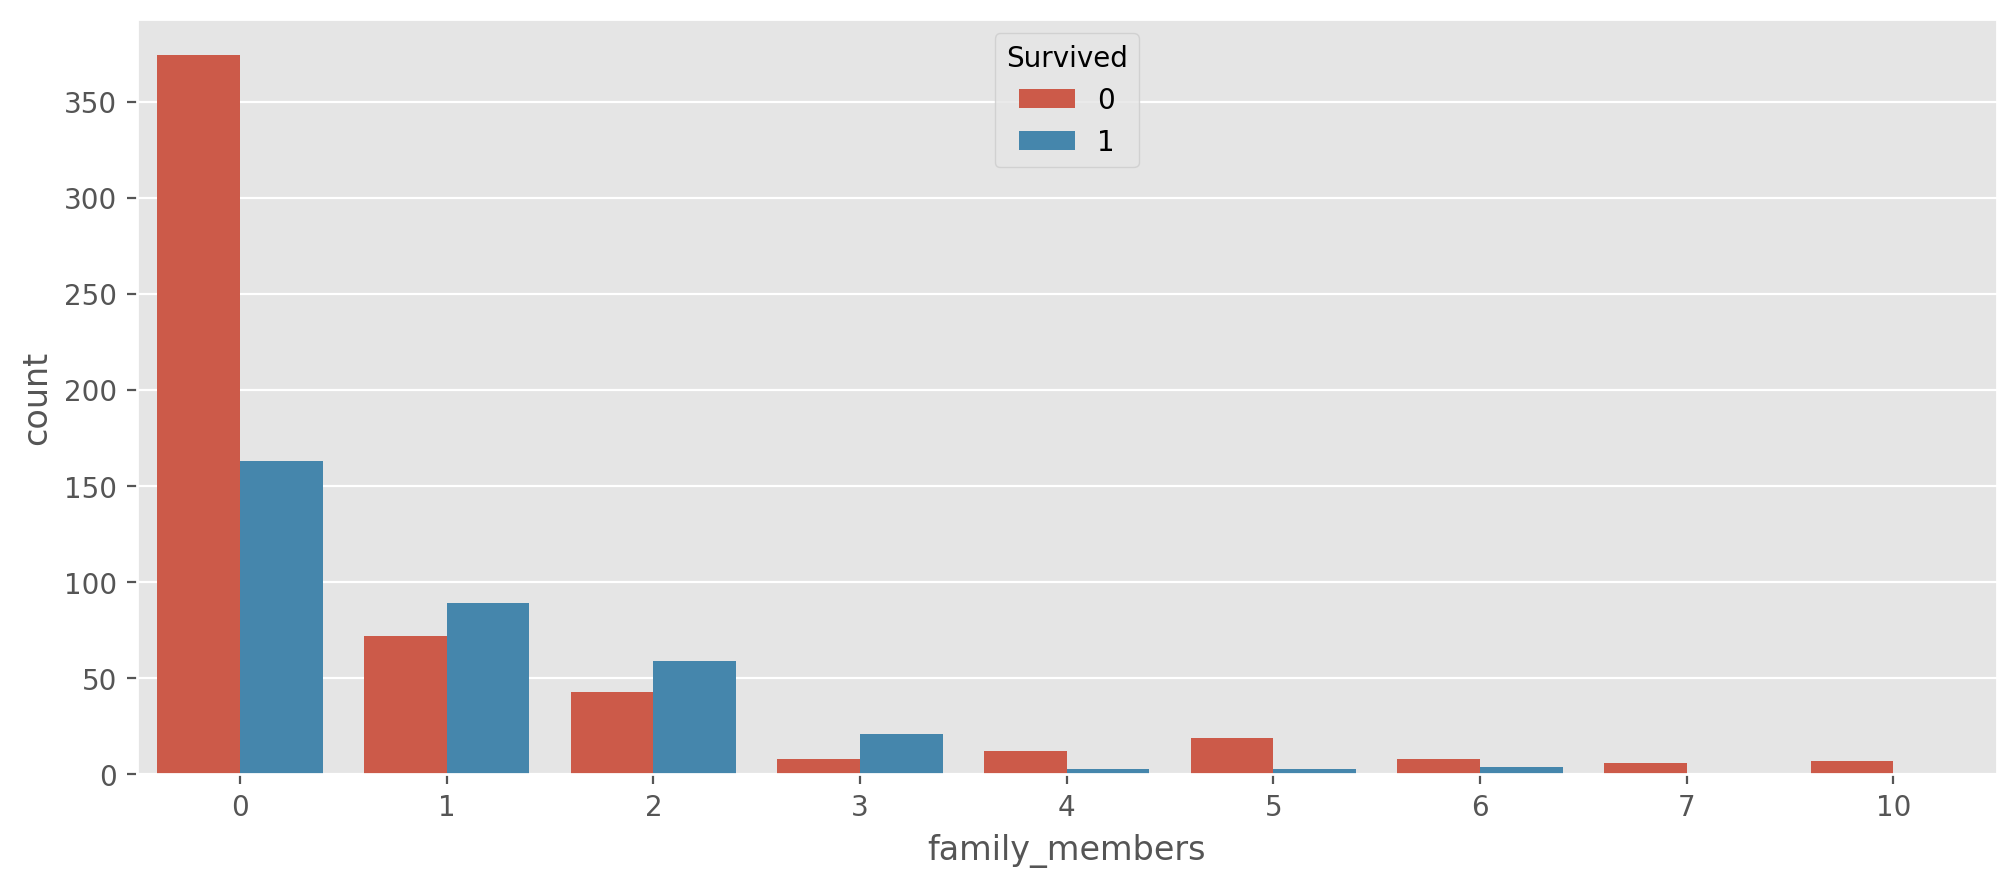

In [90]:
# Survival with respect to Embarked
plt.figure(figsize = (12,5), dpi = 200)
sns.countplot('family_members', hue = 'Survived', data = titanic)

In [91]:
q1 = titanic.Fare.quantile(0.25)
q3 = titanic.Fare.quantile(0.75)
iqr = q3 - q1
print(q1,q3,iqr)

7.9104 31.0 23.0896


In [94]:
outliers = titanic[titanic.Fare > q3 + 3*iqr].index
outliers

Int64Index([ 27,  31,  88, 118, 195, 215, 258, 268, 269, 297, 299, 305, 306,
            307, 311, 318, 319, 325, 332, 334, 337, 341, 373, 377, 380, 390,
            393, 435, 438, 498, 505, 527, 537, 544, 550, 557, 581, 609, 659,
            660, 679, 689, 698, 700, 708, 716, 730, 737, 742, 763, 779, 802,
            856],
           dtype='int64')

In [95]:
titanic.drop(outliers, axis=0)

,PassengerId,Survived,Pclass,Name,Sex,Age,Ticket,Fare,Embarked,family_members
0,1,0,3,"Braund, Mr. Owen Harris",male,22.000000,A/5 21171,7.2500,S,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.000000,PC 17599,71.2833,C,1
2,3,1,3,"Heikkinen, Miss. Laina",female,26.000000,STON/O2. 3101282,7.9250,S,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000000,113803,53.1000,S,1
4,5,0,3,"Allen, Mr. William Henry",male,35.000000,373450,8.0500,S,0
...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.000000,211536,13.0000,S,0
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.000000,112053,30.0000,S,0
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,29.699118,W./C. 6607,23.4500,S,3
889,890,1,1,"Behr, Mr. Karl Howell",male,26.000000,111369,30.0000,C,0


In [35]:
mean_fare = titanic.Fare.mean()
std_fare  = titanic.Fare.std()
z_score = (titanic.Fare.values - mean_fare)/std_fare


In [36]:
z_score

array([-5.02163137e-01,  7.86403618e-01, -4.88579852e-01,  4.20494070e-01,
       -4.86064428e-01, -4.77848050e-01,  3.95591381e-01, -2.23957338e-01,
       -4.24017995e-01, -4.29313901e-02, -3.11997147e-01, -1.13781804e-01,
       -4.86064428e-01, -1.86988098e-02, -4.90004587e-01, -3.26083517e-01,
       -6.19640877e-02, -3.86453672e-01, -2.85836747e-01, -5.02666221e-01,
       -1.24849666e-01, -3.86453672e-01, -4.86482995e-01,  6.63224922e-02,
       -2.23957338e-01, -1.64349290e-02, -5.02666221e-01,  4.64439260e+00,
       -4.89501503e-01, -4.89167454e-01, -9.02213451e-02,  2.30043680e+00,
       -4.92101444e-01, -4.36762135e-01,  1.00549697e+00,  3.98358346e-01,
       -5.02581703e-01, -4.86064428e-01, -2.85836747e-01, -4.21836620e-01,
       -4.57388605e-01, -2.25466592e-01, -4.89167454e-01,  1.88656575e-01,
       -4.89501503e-01, -4.86064428e-01, -3.36145210e-01, -4.92101444e-01,
       -2.11798788e-01, -2.89861424e-01,  1.50589167e-01, -4.91095275e-01,
        8.95993561e-01, -

In [37]:
outliers = titanic.Fare[abs(z_score) > 2].index
outliers

Index([ 27,  31,  88, 118, 195, 258, 268, 269, 297, 299, 305, 311, 318, 319,
       325, 332, 334, 337, 341, 373, 377, 380, 438, 498, 527, 557, 609, 660,
       679, 689, 700, 708, 716, 730, 737, 742, 779, 856],
      dtype='int64')

In [38]:
titanic.iloc[outliers]

,PassengerId,Survived,Pclass,Name,Sex,Age,Ticket,Fare,Embarked,family_members,...,-0.5082001520419804,-0.4810335821732919,-0.5185133868995382,0.14480369406094024,-0.3641509245671411,-0.36918177083912046,0.3680887503194546,-0.5474407529634194,-0.44992685350438916,-0.43642607444890535
27,28,0,1,"Fortune, Mr. Charles Alexander",male,19.000000,19950,263.0000,S,5,...,-0.5082,-0.481034,-0.518513,0.144804,-0.364151,-0.369182,0.368089,-0.547441,-0.449927,-0.436426
31,32,1,1,"Spencer, Mrs. William Augustus (Marie Eugenie)",female,29.699118,PC 17569,146.5208,C,1,...,-0.5082,-0.481034,-0.518513,0.144804,-0.364151,-0.369182,0.368089,-0.547441,-0.449927,-0.436426
88,89,1,1,"Fortune, Miss. Mabel Helen",female,23.000000,19950,263.0000,S,5,...,-0.5082,-0.481034,-0.518513,0.144804,-0.364151,-0.369182,0.368089,-0.547441,-0.449927,-0.436426
118,119,0,1,"Baxter, Mr. Quigg Edmond",male,24.000000,PC 17558,247.5208,C,1,...,-0.5082,-0.481034,-0.518513,0.144804,-0.364151,-0.369182,0.368089,-0.547441,-0.449927,-0.436426
195,196,1,1,"Lurette, Miss. Elise",female,58.000000,PC 17569,146.5208,C,0,...,-0.5082,-0.481034,-0.518513,0.144804,-0.364151,-0.369182,0.368089,-0.547441,-0.449927,-0.436426
258,259,1,1,"Ward, Miss. Anna",female,35.000000,PC 17755,512.3292,C,0,...,-0.5082,-0.481034,-0.518513,0.144804,-0.364151,-0.369182,0.368089,-0.547441,-0.449927,-0.436426
268,269,1,1,"Graham, Mrs. William Thompson (Edith Junkins)",female,58.000000,PC 17582,153.4625,S,1,...,-0.5082,-0.481034,-0.518513,0.144804,-0.364151,-0.369182,0.368089,-0.547441,-0.449927,-0.436426
269,270,1,1,"Bissette, Miss. Amelia",female,35.000000,PC 17760,135.6333,S,0,...,-0.5082,-0.481034,-0.518513,0.144804,-0.364151,-0.369182,0.368089,-0.547441,-0.449927,-0.436426
297,298,0,1,"Allison, Miss. Helen Loraine",female,2.000000,113781,151.5500,S,3,...,-0.5082,-0.481034,-0.518513,0.144804,-0.364151,-0.369182,0.368089,-0.547441,-0.449927,-0.436426
299,300,1,1,"Baxter, Mrs. James (Helene DeLaudeniere Chaput)",female,50.000000,PC 17558,247.5208,C,1,...,-0.5082,-0.481034,-0.518513,0.144804,-0.364151,-0.369182,0.368089,-0.547441,-0.449927,-0.436426


In [39]:
df = sns.load_dataset("titanic")
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True
